## Figure to demonstrate the effect of subsetting the biovolume in the size spectra from the models (Figure S2).

In [7]:
    # objective: generate the particle size structure for the CMIP6 models
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import xarray as xr
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob,os,subprocess
from glob import glob
import IPython.display as display
from datetime import datetime as dt
%matplotlib inline
from scipy.stats import linregress
import math

## CESM

In [8]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_CESM_PSS_hist_biovolume.nc')

In [9]:
ds_hist

<xarray.Dataset>
Dimensions:               (lat: 180, lon: 360, time: 348, biovol_um3: 50)
Coordinates:
  * lat                   (lat) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                   (lon) float64 -179.5 -178.5 -177.5 ... 178.5 179.5
  * biovol_um3            (biovol_um3) float64 0.08765 0.144 ... 3.286e+09
  * time                  (time) datetime64[ns] 1985-01-15 ... 2013-12-15
Data variables: (12/16)
    biomes                (lat, lon, time) float64 dask.array<chunksize=(180, 360, 348), meta=np.ndarray>
    NB                    (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 348, 180, 360), meta=np.ndarray>
    total_biovolume_hist  (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    betas_hist            (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    intercept_hist        (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    R2_hist               (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    ...                    ...
    total_biovolume_full  (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    phypico_per           (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    phydiat_per           (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    zooc_per              (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    phyc                  (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    chl                   (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>

In [10]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phypico'] = ds_hist.phypico.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zooc'] = ds_hist.zooc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,222202930899466.3
1,phypico,101839482585129.97
2,zooc,60677494479644.86


In [11]:
sizes=np.linspace(np.log10(0.5),np.log10(2.*1000.),num=1000,endpoint=False)
#10**(sizes)
#sizes

In [12]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [13]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes > 0.5) & (sizedf.sizes < 10),'phyto']='phypico'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 2000),'zoo']='zooc'
#sizedf.loc[(sizedf.sizes > 2000) & (sizedf.sizes < 20000),'zoo']='lgz'
##this step is necessary to remove the empty categories when we are not considering phymisc



sizedf = sizedf.reset_index(drop=True)


In [14]:
sizedf

,sizes,phyto,zoo
0,0.500000,None,None
1,0.504164,phypico,None
2,0.508363,phypico,None
3,0.512597,phypico,None
4,0.516866,phypico,None
...,...,...,...
995,1918.755756,None,zooc
996,1934.736191,None,zooc
997,1950.849720,None,zooc
998,1967.097451,None,zooc


In [15]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm = sdfm.dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm['biovolume_um3']=(4/3)*math.pi*(sdfm.sizes/2)**3
#sdfm

In [16]:
sdfm

,sizes,type,name,biovolume_um3
0,0.504164,phyto,phypico,6.709881e-02
1,0.508363,phyto,phypico,6.878932e-02
2,0.512597,phyto,phypico,7.052241e-02
3,0.516866,phyto,phypico,7.229918e-02
4,0.521171,phyto,phypico,7.412070e-02
...,...,...,...,...
1271,1918.755756,zoo,zooc,3.698773e+09
1272,1934.736191,zoo,zooc,3.791961e+09
1273,1950.849720,zoo,zooc,3.887497e+09
1274,1967.097451,zoo,zooc,3.985440e+09


In [17]:

sdfm['globalSum_m3_split']=0
for s in sdfm.name.unique():
    n=len(sdfm.loc[sdfm.name==s].index)
    print(s, n)
    sdfm.loc[sdfm.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
sdfm

phypico 361
phydiat 277
zooc 638


,sizes,type,name,biovolume_um3,globalSum_m3_split
0,0.504164,phyto,phypico,6.709881e-02,282103829875.706299
1,0.508363,phyto,phypico,6.878932e-02,282103829875.706299
2,0.512597,phyto,phypico,7.052241e-02,282103829875.706299
3,0.516866,phyto,phypico,7.229918e-02,282103829875.706299
4,0.521171,phyto,phypico,7.412070e-02,282103829875.706299
...,...,...,...,...,...
1271,1918.755756,zoo,zooc,3.698773e+09,95105790720.446487
1272,1934.736191,zoo,zooc,3.791961e+09,95105790720.446487
1273,1950.849720,zoo,zooc,3.887497e+09,95105790720.446487
1274,1967.097451,zoo,zooc,3.985440e+09,95105790720.446487


In [18]:
sdfm = sdfm.sort_values(by='biovolume_um3', ascending=True)

In [19]:
small_increment_biovol = (sdfm['biovolume_um3'][1]-sdfm['biovolume_um3'][0])/2 # small increment is used to define the maximum and minimum of the size range

In [20]:
small_increment_biovol = (sdfm['biovolume_um3'][1]-sdfm['biovolume_um3'][0])/2 # small increment is used to define the maximum and minimum of the size range
# create log-spaced bins for mg_carbon
bins_biovol = np.logspace(np.log10(sdfm['biovolume_um3'].min()-small_increment_biovol), np.log10(sdfm['biovolume_um3'].max()+small_increment_biovol), 51)


# use pandas.cut to bin the data into log-spaced bins
sdfm['biovolume_um3_bin'] = pd.cut(sdfm['biovolume_um3'], bins=bins_biovol, include_lowest=False)
sdfm['bin_centers_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.mid).astype(float) # this gets the mid point 
sdfm['bin_range_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.length).astype(float)

#len(sdfm)

In [21]:
sdfm.head()

,sizes,type,name,biovolume_um3,globalSum_m3_split,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol
0,0.504164,phyto,phypico,0.067099,282103829875.706299,"(0.0663, 0.109]",0.08765,0.0427
1,0.508363,phyto,phypico,0.068789,282103829875.706299,"(0.0663, 0.109]",0.08765,0.0427
2,0.512597,phyto,phypico,0.070522,282103829875.706299,"(0.0663, 0.109]",0.08765,0.0427
3,0.516866,phyto,phypico,0.072299,282103829875.706299,"(0.0663, 0.109]",0.08765,0.0427
4,0.521171,phyto,phypico,0.074121,282103829875.706299,"(0.0663, 0.109]",0.08765,0.0427


In [22]:
len(sdfm)

1276

In [23]:
df_grouped_biovol = sdfm.groupby(['biovolume_um3_bin','bin_centers_biovol', 'bin_range_biovol']).agg(biovolume_um3=('biovolume_um3','mean'), globalSum_um3=('globalSum_m3_split','sum'),
                                                                                                             sizes=('sizes','mean'))


df_grouped_biovol = df_grouped_biovol.dropna().sort_values(by = ['sizes']).reset_index()
df_grouped_biovol['NB'] = df_grouped_biovol.globalSum_um3/df_grouped_biovol.bin_range_biovol
df_grouped_biovol.sizes = df_grouped_biovol.sizes.round(1)
df_grouped_biovol

# Ensure numeric values
df_grouped_biovol['bin_centers_biovol'] = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
df_grouped_biovol['NB'] = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

df_grouped_subset = df_grouped_biovol[(df_grouped_biovol['bin_centers_biovol'] > 8.2e5) & (df_grouped_biovol['bin_centers_biovol'] < 2.8e13)]

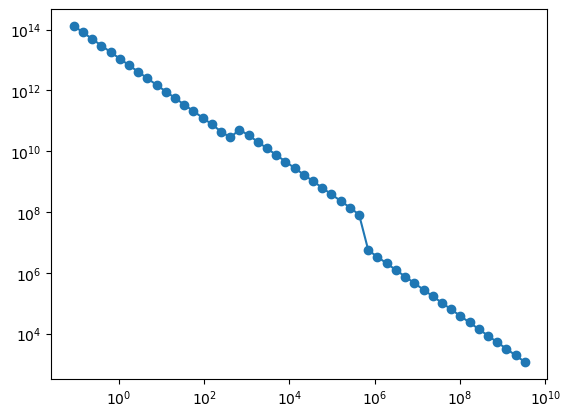

In [24]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')

In [25]:
df_grouped_biovol

,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol,biovolume_um3,globalSum_um3,sizes,NB
0,"(0.0663, 0.109]",8.765000e-02,4.270000e-02,8.586862e-02,5642076597514.123047,0.5,1.321329e+14
1,"(0.109, 0.179]",1.440000e-01,7.000000e-02,1.412401e-01,5642076597514.123047,0.6,8.060109e+13
2,"(0.179, 0.294]",2.365000e-01,1.150000e-01,2.323174e-01,5642076597514.123047,0.8,4.906154e+13
3,"(0.294, 0.484]",3.890000e-01,1.900000e-01,3.821248e-01,5642076597514.123047,0.9,2.969514e+13
4,"(0.484, 0.795]",6.395000e-01,3.110000e-01,6.285341e-01,5642076597514.123047,1.1,1.814173e+13
5,"(0.795, 1.306]",1.050500e+00,5.110000e-01,1.033838e+00,5642076597514.123047,1.3,1.104125e+13
6,"(1.306, 2.147]",1.726500e+00,8.410000e-01,1.700498e+00,5642076597514.123047,1.5,6.708771e+12
7,"(2.147, 3.529]",2.838000e+00,1.382000e+00,2.797046e+00,5642076597514.123047,1.7,4.082545e+12
8,"(3.529, 5.8]",4.664500e+00,2.271000e+00,4.600693e+00,5642076597514.123047,2.1,2.484402e+12
9,"(5.8, 9.533]",7.666500e+00,3.733000e+00,7.567403e+00,5642076597514.123047,2.4,1.511405e+12


In [26]:
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x=np.log10(df_grouped_biovol.bin_centers_biovol), y=np.log10(df_grouped_biovol.NB))

In [27]:
slope_full

-1.06041243302638

In [28]:
10**(intercept_full)

19442843977487.473

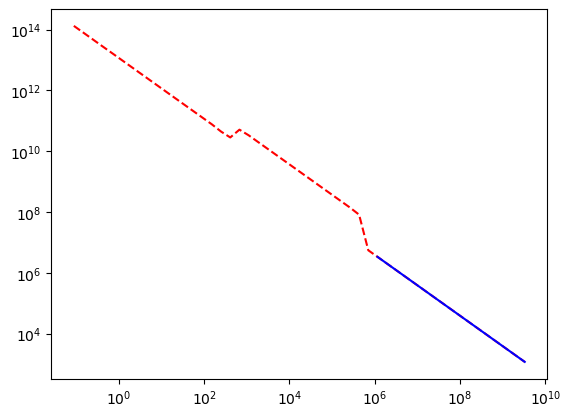

In [29]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], 'r--')
plt.plot(df_grouped_subset['bin_centers_biovol'], df_grouped_subset['NB'], 'b-')
plt.xscale('log')
plt.yscale('log')

In [30]:
df_grouped_biovol_CESM = df_grouped_biovol
df_grouped_subset_CESM = df_grouped_subset

del df_grouped_biovol
del df_grouped_subset

In [31]:
# Ensure numeric dtype and drop NaNs or non-positive values
#x = pd.to_numeric(df_grouped_subset['bin_centers_biovol'], errors='coerce')
#y = pd.to_numeric(df_grouped_subset['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
#mask = (x > 0) & (y > 0)

#x_log = np.log10(x[mask])
#y_log = np.log10(y[mask])

#slope_subset, intercept_subset, r_value_subset, p_value_subset, std_err_subset = linregress(x_log, y_log)

## CMCC

In [32]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_CMCC_PSS_hist_biovolume.nc')

In [33]:
ds_hist

<xarray.Dataset>
Dimensions:                            (lat: 180, lon: 360, time: 360,
                                        biovol_um3: 50)
Coordinates:
  * time                               (time) datetime64[ns] 1985-01-16 ... 2...
  * lat                                (lat) float64 -89.5 -88.5 ... 88.5 89.5
  * lon                                (lon) float64 -179.5 -178.5 ... 179.5
  * biovol_um3                         (biovol_um3) float64 5.939 ... 1.697e+13
Data variables: (12/21)
    biomes                             (lat, lon, time) float64 dask.array<chunksize=(180, 360, 360), meta=np.ndarray>
    chl                                (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    NB                                 (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 360, 180, 360), meta=np.ndarray>
    total_biovolume_hist_not_standard  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    betas_hist                         (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    intercept_hist                     (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    ...                                 ...
    zmicro_per                         (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zmeso_per                          (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phyc                               (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zooc                               (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    biovol_per_size_class              (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 360, 180, 360), meta=np.ndarray>
    total_biovolume_hist               (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>

In [34]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmeso.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,166162650827433.53
1,phymisc,74556402727603.77
2,zmeso,12899215410637.693
3,zmicro,9825679845126.596


In [35]:
sizes=np.linspace(np.log10(2),np.log10(35.*1000.),num=1000,endpoint=False)
#10**(sizes)
#sizes

In [36]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [37]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes > 2) & (sizedf.sizes < 20),'phyto']='phymisc'
sizedf.loc[(sizedf.sizes > 20) & (sizedf.sizes < 200),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 20) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 35000),'zoo']='zmeso'


sizedf = sizedf.reset_index(drop=True)


In [38]:
sizedf

,sizes,phyto,zoo
0,2.000000,None,None
1,2.019636,phymisc,None
2,2.039464,phymisc,None
3,2.059487,phymisc,None
4,2.079707,phymisc,None
...,...,...,...
995,33331.346172,None,zmeso
996,33658.587928,None,zmeso
997,33989.042491,None,zmeso
998,34322.741404,None,zmeso


In [39]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm = sdfm.dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm['biovolume_um3']=(4/3)*math.pi*(sdfm.sizes/2)**3
#sdfm

In [40]:
sdfm

,sizes,type,name,biovolume_um3
0,2.019636,phyto,phymisc,4.313380e+00
1,2.039464,phyto,phymisc,4.441676e+00
2,2.059487,phyto,phymisc,4.573787e+00
3,2.079707,phyto,phymisc,4.709828e+00
4,2.100125,phyto,phymisc,4.849916e+00
...,...,...,...,...
1230,33331.346172,zoo,zmeso,1.938908e+13
1231,33658.587928,zoo,zmeso,1.996578e+13
1232,33989.042491,zoo,zmeso,2.055964e+13
1233,34322.741404,zoo,zmeso,2.117115e+13


In [41]:

sdfm['globalSum_m3_split']=0
for s in sdfm.name.unique():
    n=len(sdfm.loc[sdfm.name==s].index)
    print(s, n)
    sdfm.loc[sdfm.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
sdfm

phymisc 235
phydiat 236
zmicro 236
zmeso 528


,sizes,type,name,biovolume_um3,globalSum_m3_split
0,2.019636,phyto,phymisc,4.313380e+00,317261288202.569214
1,2.039464,phyto,phymisc,4.441676e+00,317261288202.569214
2,2.059487,phyto,phymisc,4.573787e+00,317261288202.569214
3,2.079707,phyto,phymisc,4.709828e+00,317261288202.569214
4,2.100125,phyto,phymisc,4.849916e+00,317261288202.569214
...,...,...,...,...,...
1230,33331.346172,zoo,zmeso,1.938908e+13,24430332217.116844
1231,33658.587928,zoo,zmeso,1.996578e+13,24430332217.116844
1232,33989.042491,zoo,zmeso,2.055964e+13,24430332217.116844
1233,34322.741404,zoo,zmeso,2.117115e+13,24430332217.116844


In [42]:
sdfm = sdfm.sort_values(by='biovolume_um3', ascending=True)

In [43]:
small_increment_biovol = (sdfm['biovolume_um3'][1]-sdfm['biovolume_um3'][0])/2 # small increment is used to define the maximum and minimum of the size range

In [44]:
# create log-spaced bins for mg_carbon
bins_biovol = np.logspace(np.log10(sdfm['biovolume_um3'].min()-small_increment_biovol), np.log10(sdfm['biovolume_um3'].max()+small_increment_biovol), 51)


# use pandas.cut to bin the data into log-spaced bins
sdfm['biovolume_um3_bin'] = pd.cut(sdfm['biovolume_um3'], bins=bins_biovol, include_lowest=False)
sdfm['bin_centers_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.mid).astype(float) # this gets the mid point 
sdfm['bin_range_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.length).astype(float)

#len(sdfm)

In [45]:
sdfm.head()

,sizes,type,name,biovolume_um3,globalSum_m3_split,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol
0,2.019636,phyto,phymisc,4.313380,317261288202.569214,"(4.249, 7.63]",5.9395,3.381
1,2.039464,phyto,phymisc,4.441676,317261288202.569214,"(4.249, 7.63]",5.9395,3.381
2,2.059487,phyto,phymisc,4.573787,317261288202.569214,"(4.249, 7.63]",5.9395,3.381
3,2.079707,phyto,phymisc,4.709828,317261288202.569214,"(4.249, 7.63]",5.9395,3.381
4,2.100125,phyto,phymisc,4.849916,317261288202.569214,"(4.249, 7.63]",5.9395,3.381


In [46]:
len(sdfm)

1235

In [47]:
df_grouped_biovol = sdfm.groupby(['biovolume_um3_bin','bin_centers_biovol', 'bin_range_biovol']).agg(biovolume_um3=('biovolume_um3','mean'), globalSum_um3=('globalSum_m3_split','sum'),
                                                                                                             sizes=('sizes','mean'))


df_grouped_biovol = df_grouped_biovol.dropna().sort_values(by = ['sizes']).reset_index()
df_grouped_biovol['NB'] = df_grouped_biovol.globalSum_um3/df_grouped_biovol.bin_range_biovol
df_grouped_biovol.sizes = df_grouped_biovol.sizes.round(1)
df_grouped_biovol

# Ensure numeric values
df_grouped_biovol['bin_centers_biovol'] = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
df_grouped_biovol['NB'] = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

df_grouped_subset = df_grouped_biovol[(df_grouped_biovol['bin_centers_biovol'] > 8.2e5) & (df_grouped_biovol['bin_centers_biovol'] < 2.8e13)]

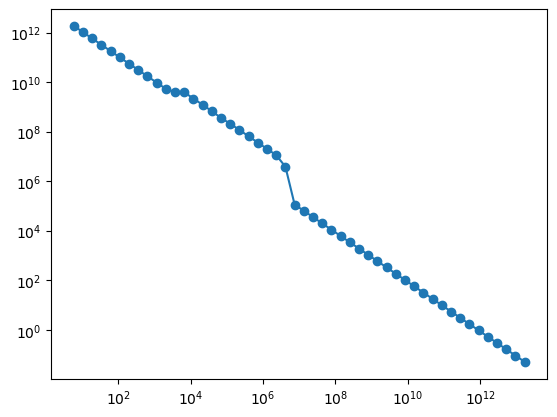

In [48]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')

In [49]:
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x=np.log10(df_grouped_biovol.bin_centers_biovol), y=np.log10(df_grouped_biovol.NB))

In [50]:

# Ensure numeric dtype and drop NaNs or non-positive values
x = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
y = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
mask = (x > 0) & (y > 0)

x_log = np.log10(x[mask])
y_log = np.log10(y[mask])

slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x_log, y_log)

In [51]:
slope_full

-1.1434821481302326

In [52]:
10**(intercept_full)

36284874899945.74

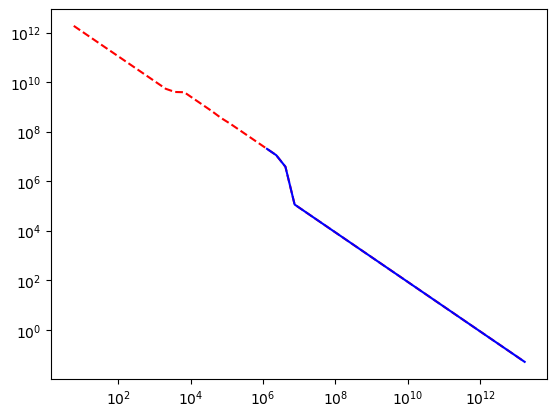

In [53]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], 'r--')
plt.plot(df_grouped_subset['bin_centers_biovol'], df_grouped_subset['NB'], 'b-')
plt.xscale('log')
plt.yscale('log')

In [54]:
df_grouped_biovol_CMCC = df_grouped_biovol
df_grouped_subset_CMCC = df_grouped_subset

del df_grouped_biovol
del df_grouped_subset

In [55]:
# Ensure numeric dtype and drop NaNs or non-positive values
#x = pd.to_numeric(df_grouped_subset['bin_centers_biovol'], errors='coerce')
#y = pd.to_numeric(df_grouped_subset['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
#mask = (x > 0) & (y > 0)

#x_log = np.log10(x[mask])
#y_log = np.log10(y[mask])

#slope_subset, intercept_subset, r_value_subset, p_value_subset, std_err_subset = linregress(x_log, y_log)

## CNRM

In [56]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_CNRM_PSS_hist_biovolume.nc')

In [57]:
ds_hist

<xarray.Dataset>
Dimensions:               (lat: 180, lon: 360, time: 360, biovol_um3: 50)
Coordinates:
  * time                  (time) datetime64[ns] 1985-01-18 ... 2014-12-25
  * lat                   (lat) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                   (lon) float64 -179.5 -178.5 -177.5 ... 178.5 179.5
  * biovol_um3            (biovol_um3) float64 0.682 1.075 ... 3.346e+09
Data variables: (12/19)
    biomes                (lat, lon, time) float64 dask.array<chunksize=(180, 360, 360), meta=np.ndarray>
    chl                   (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    NB                    (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 360, 180, 360), meta=np.ndarray>
    total_biovolume_hist  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    betas_hist            (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    intercept_hist        (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    ...                    ...
    phymisc_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phydiat_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zmicro_per            (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zmeso_per             (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phyc                  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zooc                  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>

In [58]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmeso.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,9265062658192028.0
1,phymisc,565730365962910.8
2,zmeso,22010354231028.184
3,zmicro,11422088520080.857


In [59]:
sizes=np.linspace(np.log10(1),np.log10(2.*1000.),num=1000,endpoint=False)
#10**(sizes)
#sizes

In [60]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [61]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes >1) & (sizedf.sizes < 10),'phyto']='phymisc'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 40),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 2000),'zoo']='zmeso'


sizedf = sizedf.reset_index(drop=True)


In [62]:
sizedf

,sizes,phyto,zoo
0,1.000000,None,None
1,1.007630,phymisc,None
2,1.015318,phymisc,None
3,1.023065,phymisc,None
4,1.030871,phymisc,None
...,...,...,...
995,1925.417194,None,zmeso
996,1940.107862,None,zmeso
997,1954.910619,None,zmeso
998,1969.826318,None,zmeso


In [63]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm = sdfm.dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm['biovolume_um3']=(4/3)*math.pi*(sdfm.sizes/2)**3
#sdfm

In [64]:
sdfm

,sizes,type,name,biovolume_um3
0,1.007630,phyto,phymisc,5.356754e-01
1,1.015318,phyto,phymisc,5.480306e-01
2,1.023065,phyto,phymisc,5.606707e-01
3,1.030871,phyto,phymisc,5.736024e-01
4,1.038736,phyto,phymisc,5.868324e-01
...,...,...,...,...
1177,1925.417194,zoo,zmeso,3.737431e+09
1178,1940.107862,zoo,zmeso,3.823633e+09
1179,1954.910619,zoo,zmeso,3.911824e+09
1180,1969.826318,zoo,zmeso,4.002049e+09


In [65]:

sdfm['globalSum_m3_split']=0
for s in sdfm.name.unique():
    n=len(sdfm.loc[sdfm.name==s].index)
    print(s, n)
    sdfm.loc[sdfm.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
sdfm

phymisc 302
phydiat 183
zmicro 395
zmeso 302


,sizes,type,name,biovolume_um3,globalSum_m3_split
0,1.007630,phyto,phymisc,5.356754e-01,1873279357493.082031
1,1.015318,phyto,phymisc,5.480306e-01,1873279357493.082031
2,1.023065,phyto,phymisc,5.606707e-01,1873279357493.082031
3,1.030871,phyto,phymisc,5.736024e-01,1873279357493.082031
4,1.038736,phyto,phymisc,5.868324e-01,1873279357493.082031
...,...,...,...,...,...
1177,1925.417194,zoo,zmeso,3.737431e+09,72881967652.411209
1178,1940.107862,zoo,zmeso,3.823633e+09,72881967652.411209
1179,1954.910619,zoo,zmeso,3.911824e+09,72881967652.411209
1180,1969.826318,zoo,zmeso,4.002049e+09,72881967652.411209


In [66]:
sdfm = sdfm.sort_values(by='biovolume_um3', ascending=True)

In [67]:
small_increment_biovol = (sdfm['biovolume_um3'][1]-sdfm['biovolume_um3'][0])/2 # small increment is used to define the maximum and minimum of the size range

In [68]:
# create log-spaced bins for mg_carbon
bins_biovol = np.logspace(np.log10(sdfm['biovolume_um3'].min()-small_increment_biovol), np.log10(sdfm['biovolume_um3'].max()+small_increment_biovol), 51)


# use pandas.cut to bin the data into log-spaced bins
sdfm['biovolume_um3_bin'] = pd.cut(sdfm['biovolume_um3'], bins=bins_biovol, include_lowest=False)
sdfm['bin_centers_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.mid).astype(float) # this gets the mid point 
sdfm['bin_range_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.length).astype(float)

#len(sdfm)

In [69]:
sdfm.head()

,sizes,type,name,biovolume_um3,globalSum_m3_split,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol
0,1.007630,phyto,phymisc,0.535675,1873279357493.082031,"(0.529, 0.835]",0.682,0.306
1,1.015318,phyto,phymisc,0.548031,1873279357493.082031,"(0.529, 0.835]",0.682,0.306
2,1.023065,phyto,phymisc,0.560671,1873279357493.082031,"(0.529, 0.835]",0.682,0.306
3,1.030871,phyto,phymisc,0.573602,1873279357493.082031,"(0.529, 0.835]",0.682,0.306
4,1.038736,phyto,phymisc,0.586832,1873279357493.082031,"(0.529, 0.835]",0.682,0.306


In [70]:
len(sdfm)

1182

In [71]:
df_grouped_biovol = sdfm.groupby(['biovolume_um3_bin','bin_centers_biovol', 'bin_range_biovol']).agg(biovolume_um3=('biovolume_um3','mean'), globalSum_um3=('globalSum_m3_split','sum'),
                                                                                                             sizes=('sizes','mean'))


df_grouped_biovol = df_grouped_biovol.dropna().sort_values(by = ['sizes']).reset_index()
df_grouped_biovol['NB'] = df_grouped_biovol.globalSum_um3/df_grouped_biovol.bin_range_biovol
df_grouped_biovol.sizes = df_grouped_biovol.sizes.round(1)
df_grouped_biovol

# Ensure numeric values
df_grouped_biovol['bin_centers_biovol'] = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
df_grouped_biovol['NB'] = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

df_grouped_subset = df_grouped_biovol[(df_grouped_biovol['bin_centers_biovol'] > 8.2e5) & (df_grouped_biovol['bin_centers_biovol'] < 2.8e13)]

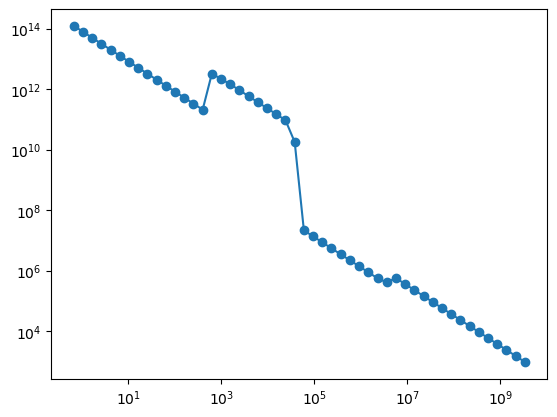

In [72]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')

In [73]:
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x=np.log10(df_grouped_biovol.bin_centers_biovol), y=np.log10(df_grouped_biovol.NB))

In [74]:

# Ensure numeric dtype and drop NaNs or non-positive values
x = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
y = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
mask = (x > 0) & (y > 0)

x_log = np.log10(x[mask])
y_log = np.log10(y[mask])

slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x_log, y_log)

In [75]:
slope_full

-1.2577745265718774

In [76]:
intercept_full

14.619417912476186

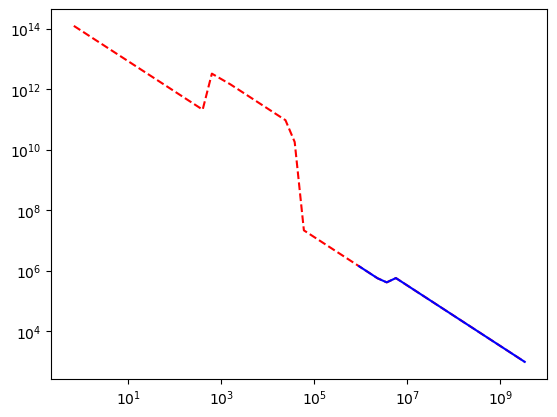

In [77]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], 'r--')
plt.plot(df_grouped_subset['bin_centers_biovol'], df_grouped_subset['NB'], 'b-')
plt.xscale('log')
plt.yscale('log')

In [78]:
df_grouped_biovol_CNRM = df_grouped_biovol
df_grouped_subset_CNRM = df_grouped_subset

del df_grouped_biovol
del df_grouped_subset

In [79]:
# Ensure numeric dtype and drop NaNs or non-positive values
#x = pd.to_numeric(df_grouped_subset['bin_centers_biovol'], errors='coerce')
#y = pd.to_numeric(df_grouped_subset['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
#mask = (x > 0) & (y > 0)

#x_log = np.log10(x[mask])
#y_log = np.log10(y[mask])

#slope_subset, intercept_subset, r_value_subset, p_value_subset, std_err_subset = linregress(x_log, y_log)

## GFDL

In [80]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_GFDL_PSS_hist_biovolume.nc')

In [81]:
ds_hist

<xarray.Dataset>
Dimensions:                            (time: 360, lat: 180, lon: 360,
                                        biovol_um3: 50)
Coordinates:
  * time                               (time) object 1985-01-16 12:00:00 ... ...
  * lat                                (lat) float64 -89.5 -88.5 ... 88.5 89.5
  * lon                                (lon) float64 -179.5 -178.5 ... 179.5
  * biovol_um3                         (biovol_um3) float64 0.09575 ... 3.104...
Data variables: (12/23)
    biomes                             (lat, lon) float64 dask.array<chunksize=(180, 360), meta=np.ndarray>
    chl                                (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    NB                                 (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 360, 180, 360), meta=np.ndarray>
    total_biovolume_hist_not_standard  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    betas_hist                         (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    intercept_hist                     (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    ...                                 ...
    zmicro_per                         (time, lat, lon) float32 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zmeso_per                          (time, lat, lon) float32 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phyc                               (time, lat, lon) float32 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zooc                               (time, lat, lon) float32 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    biovol_per_size_class              (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 360, 180, 360), meta=np.ndarray>
    total_biovolume_hist               (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>

In [82]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phypico'] = ds_hist.phypico.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmeso.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,4289286664880128.0
1,phymisc,13789172858880.0
2,phypico,5152192839286784.0
3,zmeso,272592934010880.0
4,zmicro,97937518493696.0


In [83]:
sizes=np.linspace(np.log10(0.5),np.log10(20.*1000.),num=1000,endpoint=False)
#10**(sizes)
#sizes

In [84]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [85]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['phytomisc']= None
sizedf['zoo']= None
sizedf.loc[(sizedf.sizes > 0.5) & (sizedf.sizes < 10),'phyto']='phypico'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phyto']='phydiat'
#sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phyto']='phylarge' # 12/19/2022 change sizes in phydiat and phymisc for them to match the other models (sizedf.sizes > 10) & (sizedf.sizes < 200)
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phytomisc']='phymisc'
#sizedf.loc[(sizedf.sizes > 5) & (sizedf.sizes < 22),'phyto']='phydiaz' # reference here, double check this
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 20000),'zoo']='zmeso' #updated 12/12/2022, zmeso is large and medium zoo
len(sizedf)

sizedf = sizedf.reset_index(drop=True)

sizedf

,sizes,phyto,phytomisc,zoo
0,0.500000,None,None,None
1,0.505326,phypico,None,None
2,0.510710,phypico,None,None
3,0.516150,phypico,None,None
4,0.521649,phypico,None,None
...,...,...,...,...
995,18967.919408,None,None,zmeso
996,19169.984234,None,None,zmeso
997,19374.201652,None,None,zmeso
998,19580.594595,None,None,zmeso


In [86]:
sizedf

,sizes,phyto,phytomisc,zoo
0,0.500000,None,None,None
1,0.505326,phypico,None,None
2,0.510710,phypico,None,None
3,0.516150,phypico,None,None
4,0.521649,phypico,None,None
...,...,...,...,...
995,18967.919408,None,None,zmeso
996,19169.984234,None,None,zmeso
997,19374.201652,None,None,zmeso
998,19580.594595,None,None,zmeso


In [87]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm = sdfm.dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm['biovolume_um3']=(4/3)*math.pi*(sdfm.sizes/2)**3
#sdfm

In [88]:
sdfm

,sizes,type,name,biovolume_um3
0,0.505326,phyto,phypico,6.756392e-02
1,0.510710,phyto,phypico,6.974627e-02
2,0.516150,phyto,phypico,7.199912e-02
3,0.521649,phyto,phypico,7.432473e-02
4,0.527206,phyto,phypico,7.672547e-02
...,...,...,...,...
1428,18967.919408,zoo,zmeso,3.573203e+12
1429,19169.984234,zoo,zmeso,3.688620e+12
1430,19374.201652,zoo,zmeso,3.807764e+12
1431,19580.594595,zoo,zmeso,3.930757e+12


In [89]:

sdfm['globalSum_m3_split']=0
for s in sdfm.name.unique():
    n=len(sdfm.loc[sdfm.name==s].index)
    print(s, n)
    sdfm.loc[sdfm.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
sdfm

phypico 282
phydiat 217
phymisc 217
zmicro 283
zmeso 434


,sizes,type,name,biovolume_um3,globalSum_m3_split
0,0.505326,phyto,phypico,6.756392e-02,18270187373357.390625
1,0.510710,phyto,phypico,6.974627e-02,18270187373357.390625
2,0.516150,phyto,phypico,7.199912e-02,18270187373357.390625
3,0.521649,phyto,phypico,7.432473e-02,18270187373357.390625
4,0.527206,phyto,phypico,7.672547e-02,18270187373357.390625
...,...,...,...,...,...
1428,18967.919408,zoo,zmeso,3.573203e+12,628094317997.419312
1429,19169.984234,zoo,zmeso,3.688620e+12,628094317997.419312
1430,19374.201652,zoo,zmeso,3.807764e+12,628094317997.419312
1431,19580.594595,zoo,zmeso,3.930757e+12,628094317997.419312


In [90]:
sdfm = sdfm.sort_values(by='biovolume_um3', ascending=True)

In [91]:
small_increment_biovol = (sdfm['biovolume_um3'][1]-sdfm['biovolume_um3'][0])/2 # small increment is used to define the maximum and minimum of the size range

In [92]:
# create log-spaced bins for mg_carbon
bins_biovol = np.logspace(np.log10(sdfm['biovolume_um3'].min()-small_increment_biovol), np.log10(sdfm['biovolume_um3'].max()+small_increment_biovol), 51)


# use pandas.cut to bin the data into log-spaced bins
sdfm['biovolume_um3_bin'] = pd.cut(sdfm['biovolume_um3'], bins=bins_biovol, include_lowest=False)
sdfm['bin_centers_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.mid).astype(float) # this gets the mid point 
sdfm['bin_range_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.length).astype(float)

#len(sdfm)

In [93]:
sdfm.head()

,sizes,type,name,biovolume_um3,globalSum_m3_split,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol
0,0.505326,phyto,phypico,0.067564,18270187373357.390625,"(0.0665, 0.125]",0.09575,0.0585
1,0.510710,phyto,phypico,0.069746,18270187373357.390625,"(0.0665, 0.125]",0.09575,0.0585
2,0.516150,phyto,phypico,0.071999,18270187373357.390625,"(0.0665, 0.125]",0.09575,0.0585
3,0.521649,phyto,phypico,0.074325,18270187373357.390625,"(0.0665, 0.125]",0.09575,0.0585
4,0.527206,phyto,phypico,0.076725,18270187373357.390625,"(0.0665, 0.125]",0.09575,0.0585


In [94]:
len(sdfm)

1433

In [95]:
df_grouped_biovol = sdfm.groupby(['biovolume_um3_bin','bin_centers_biovol', 'bin_range_biovol']).agg(biovolume_um3=('biovolume_um3','mean'), globalSum_um3=('globalSum_m3_split','sum'),
                                                                                                             sizes=('sizes','mean'))


df_grouped_biovol = df_grouped_biovol.dropna().sort_values(by = ['sizes']).reset_index()
df_grouped_biovol['NB'] = df_grouped_biovol.globalSum_um3/df_grouped_biovol.bin_range_biovol
df_grouped_biovol.sizes = df_grouped_biovol.sizes.round(1)
df_grouped_biovol

# Ensure numeric values
df_grouped_biovol['bin_centers_biovol'] = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
df_grouped_biovol['NB'] = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

df_grouped_subset = df_grouped_biovol[(df_grouped_biovol['bin_centers_biovol'] > 8.2e5) & (df_grouped_biovol['bin_centers_biovol'] < 2.8e13)]

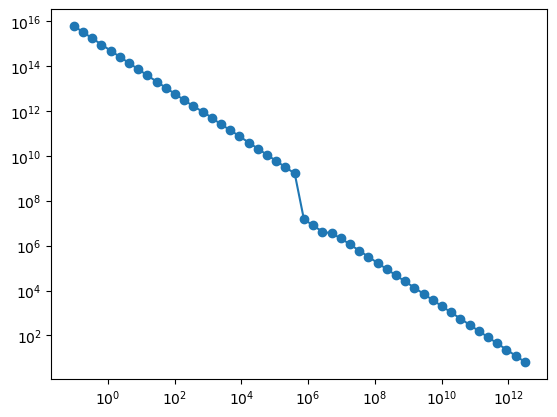

In [96]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')

In [97]:
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x=np.log10(df_grouped_biovol.bin_centers_biovol), y=np.log10(df_grouped_biovol.NB))

In [98]:

# Ensure numeric dtype and drop NaNs or non-positive values
x = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
y = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
mask = (x > 0) & (y > 0)

x_log = np.log10(x[mask])
y_log = np.log10(y[mask])

slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x_log, y_log)

In [99]:
slope_full

-1.1606395642728369

In [100]:
intercept_full

14.95624583593371

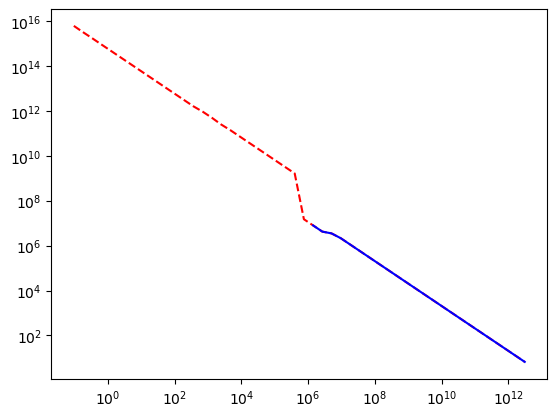

In [101]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], 'r--')
plt.plot(df_grouped_subset['bin_centers_biovol'], df_grouped_subset['NB'], 'b-')
plt.xscale('log')
plt.yscale('log')

In [102]:
df_grouped_biovol_GFDL = df_grouped_biovol
df_grouped_subset_GFDL = df_grouped_subset

del df_grouped_biovol
del df_grouped_subset

In [103]:
# Ensure numeric dtype and drop NaNs or non-positive values
#x = pd.to_numeric(df_grouped_subset['bin_centers_biovol'], errors='coerce')
#y = pd.to_numeric(df_grouped_subset['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
#mask = (x > 0) & (y > 0)

#x_log = np.log10(x[mask])
#y_log = np.log10(y[mask])

#slope_subset, intercept_subset, r_value_subset, p_value_subset, std_err_subset = linregress(x_log, y_log)

## GISS

In [104]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_GISS_PSS_hist_biovolume.nc')

In [105]:
ds_hist

<xarray.Dataset>
Dimensions:               (lat: 180, lon: 360, time: 360, biovol_um3: 50)
Coordinates:
  * time                  (time) datetime64[ns] 1985-01-16 ... 2014-12-16
  * lat                   (lat) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                   (lon) float64 -179.5 -178.5 -177.5 ... 178.5 179.5
  * biovol_um3            (biovol_um3) float64 5.316 8.041 ... 3.408e+09
Data variables: (12/18)
    biomes                (lat, lon, time) float64 dask.array<chunksize=(180, 360, 360), meta=np.ndarray>
    chl                   (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    NB                    (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 360, 180, 360), meta=np.ndarray>
    total_biovolume_hist  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    betas_hist            (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    intercept_hist        (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    ...                    ...
    total_biovolume_full  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phycalc_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phymisc_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phydiat_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zooc_per              (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phyc                  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>

In [106]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phycalc'] = ds_hist.phycalc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zooc'] = ds_hist.zooc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phycalc,9.510907574597976e+16
1,phydiat,1520762045807.754
2,phymisc,661070473578.5247
3,zooc,19751452047641.867


In [107]:
sizes=np.linspace(np.log10(2),np.log10(2.*1000.),num=1000,endpoint=False)
#10**(sizes)
#sizes

In [108]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [109]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['phytomisc']= None # withoutphytomisc, phymisc information dissapears (it is all masked by phycalc)
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes > 2) & (sizedf.sizes < 10),'phytomisc']='phymisc'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 100),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 2) & (sizedf.sizes < 75),'phyto']='phycalc'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 2000),'zoo']='zooc'


sizedf = sizedf.reset_index(drop=True)


In [110]:
sizedf

,sizes,phyto,phytomisc,zoo
0,2.000000,None,None,None
1,2.013863,phycalc,phymisc,None
2,2.027823,phycalc,phymisc,None
3,2.041879,phycalc,phymisc,None
4,2.056033,phycalc,phymisc,None
...,...,...,...,...
995,1932.101758,None,None,zooc
996,1945.494448,None,None,zooc
997,1958.979971,None,None,zooc
998,1972.558971,None,None,zooc


In [111]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm = sdfm.dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm['biovolume_um3']=(4/3)*math.pi*(sdfm.sizes/2)**3
#sdfm

In [112]:
sdfm

,sizes,type,name,biovolume_um3
0,2.013863,phyto,phycalc,4.276501e+00
1,2.027823,phyto,phycalc,4.366049e+00
2,2.041879,phyto,phycalc,4.457472e+00
3,2.056033,phyto,phycalc,4.550809e+00
4,2.070284,phyto,phycalc,4.646101e+00
...,...,...,...,...
1560,1932.101758,zoo,zooc,3.776492e+09
1561,1945.494448,zoo,zooc,3.855570e+09
1562,1958.979971,zoo,zooc,3.936304e+09
1563,1972.558971,zoo,zooc,4.018728e+09


In [113]:

sdfm['globalSum_m3_split']=0
for s in sdfm.name.unique():
    n=len(sdfm.loc[sdfm.name==s].index)
    print(s, n)
    sdfm.loc[sdfm.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
sdfm

phycalc 524
phydiat 42
phymisc 232
zooc 767


,sizes,type,name,biovolume_um3,globalSum_m3_split
0,2.013863,phyto,phycalc,4.276501e+00,181505869744236.1875
1,2.027823,phyto,phycalc,4.366049e+00,181505869744236.1875
2,2.041879,phyto,phycalc,4.457472e+00,181505869744236.1875
3,2.056033,phyto,phycalc,4.550809e+00,181505869744236.1875
4,2.070284,phyto,phycalc,4.646101e+00,181505869744236.1875
...,...,...,...,...,...
1560,1932.101758,zoo,zooc,3.776492e+09,25751567206.834248
1561,1945.494448,zoo,zooc,3.855570e+09,25751567206.834248
1562,1958.979971,zoo,zooc,3.936304e+09,25751567206.834248
1563,1972.558971,zoo,zooc,4.018728e+09,25751567206.834248


In [114]:
sdfm = sdfm.sort_values(by='biovolume_um3', ascending=True)

In [115]:
small_increment_biovol = (sdfm['biovolume_um3'][1]-sdfm['biovolume_um3'][0])/2 # small increment is used to define the maximum and minimum of the size range

In [116]:
# create log-spaced bins for mg_carbon
bins_biovol = np.logspace(np.log10(sdfm['biovolume_um3'].min()-small_increment_biovol), np.log10(sdfm['biovolume_um3'].max()+small_increment_biovol), 51)


# use pandas.cut to bin the data into log-spaced bins
sdfm['biovolume_um3_bin'] = pd.cut(sdfm['biovolume_um3'], bins=bins_biovol, include_lowest=False)
sdfm['bin_centers_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.mid).astype(float) # this gets the mid point 
sdfm['bin_range_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.length).astype(float)

#len(sdfm)

In [117]:
sdfm.head()

,sizes,type,name,biovolume_um3,globalSum_m3_split,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol
0,2.013863,phyto,phycalc,4.276501,181505869744236.1875,"(4.232, 6.401]",5.3165,2.169
566,2.013863,phytomisc,phymisc,4.276501,2849441696.459158,"(4.232, 6.401]",5.3165,2.169
567,2.027823,phytomisc,phymisc,4.366049,2849441696.459158,"(4.232, 6.401]",5.3165,2.169
1,2.027823,phyto,phycalc,4.366049,181505869744236.1875,"(4.232, 6.401]",5.3165,2.169
2,2.041879,phyto,phycalc,4.457472,181505869744236.1875,"(4.232, 6.401]",5.3165,2.169


In [118]:
len(sdfm)

1565

In [119]:
df_grouped_biovol = sdfm.groupby(['biovolume_um3_bin','bin_centers_biovol', 'bin_range_biovol']).agg(biovolume_um3=('biovolume_um3','mean'), globalSum_um3=('globalSum_m3_split','sum'),
                                                                                                             sizes=('sizes','mean'))


df_grouped_biovol = df_grouped_biovol.dropna().sort_values(by = ['sizes']).reset_index()
df_grouped_biovol['NB'] = df_grouped_biovol.globalSum_um3/df_grouped_biovol.bin_range_biovol
df_grouped_biovol.sizes = df_grouped_biovol.sizes.round(1)
df_grouped_biovol

# Ensure numeric values
df_grouped_biovol['bin_centers_biovol'] = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
df_grouped_biovol['NB'] = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

df_grouped_subset = df_grouped_biovol[(df_grouped_biovol['bin_centers_biovol'] > 8.2e5) & (df_grouped_biovol['bin_centers_biovol'] < 2.8e13)]

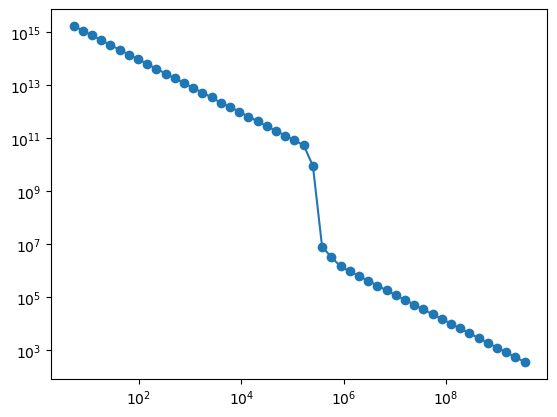

In [120]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')

In [121]:
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x=np.log10(df_grouped_biovol.bin_centers_biovol), y=np.log10(df_grouped_biovol.NB))

In [122]:

# Ensure numeric dtype and drop NaNs or non-positive values
x = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
y = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
mask = (x > 0) & (y > 0)

x_log = np.log10(x[mask])
y_log = np.log10(y[mask])

slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x_log, y_log)

In [123]:
slope_full

-1.6380021059080216

In [124]:
intercept_full

17.450079900596414

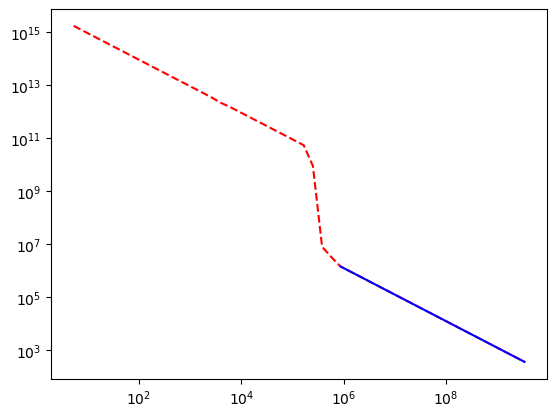

In [125]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], 'r--')
plt.plot(df_grouped_subset['bin_centers_biovol'], df_grouped_subset['NB'], 'b-')
plt.xscale('log')
plt.yscale('log')

In [126]:
df_grouped_biovol_GISS = df_grouped_biovol
df_grouped_subset_GISS = df_grouped_subset

del df_grouped_biovol
del df_grouped_subset

In [127]:
# Ensure numeric dtype and drop NaNs or non-positive values
#x = pd.to_numeric(df_grouped_subset['bin_centers_biovol'], errors='coerce')
#y = pd.to_numeric(df_grouped_subset['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
#mask = (x > 0) & (y > 0)

#x_log = np.log10(x[mask])
#y_log = np.log10(y[mask])

#slope_subset, intercept_subset, r_value_subset, p_value_subset, std_err_subset = linregress(x_log, y_log)

## IPSL

In [128]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_IPSL_PSS_hist_biovolume.nc')

In [129]:
ds_hist

<xarray.Dataset>
Dimensions:               (lat: 180, lon: 360, time: 359, biovol_um3: 50)
Coordinates:
  * time                  (time) datetime64[ns] 1985-02-18 ... 2014-12-25
  * lat                   (lat) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                   (lon) float64 -179.5 -178.5 -177.5 ... 178.5 179.5
  * biovol_um3            (biovol_um3) float64 0.682 1.075 ... 3.346e+09
Data variables: (12/19)
    biomes                (lat, lon, time) float64 dask.array<chunksize=(180, 360, 359), meta=np.ndarray>
    chl                   (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    NB                    (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 359, 180, 360), meta=np.ndarray>
    total_biovolume_hist  (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    betas_hist            (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    intercept_hist        (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    ...                    ...
    phymisc_per           (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    phydiat_per           (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    zmicro_per            (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    zmeso_per             (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    phyc                  (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>
    zooc                  (time, lat, lon) float64 dask.array<chunksize=(359, 180, 360), meta=np.ndarray>

In [130]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmeso.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,6495740637723786.0
1,phymisc,541311010072799.06
2,zmeso,13763889285901.318
3,zmicro,7657069048129.031


In [131]:
sizes=np.linspace(np.log10(1),np.log10(2.*1000.),num=1000,endpoint=False)
#10**(sizes)
#sizes

In [132]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [133]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes >1) & (sizedf.sizes < 10),'phyto']='phymisc'
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 40),'phyto']='phydiat' ##Playing with diatom size 
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 2000),'zoo']='zmeso'


sizedf = sizedf.reset_index(drop=True)


In [134]:
sizedf

,sizes,phyto,zoo
0,1.000000,None,None
1,1.007630,phymisc,None
2,1.015318,phymisc,None
3,1.023065,phymisc,None
4,1.030871,phymisc,None
...,...,...,...
995,1925.417194,None,zmeso
996,1940.107862,None,zmeso
997,1954.910619,None,zmeso
998,1969.826318,None,zmeso


In [135]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm = sdfm.dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm['biovolume_um3']=(4/3)*math.pi*(sdfm.sizes/2)**3
#sdfm

In [136]:
sdfm

,sizes,type,name,biovolume_um3
0,1.007630,phyto,phymisc,5.356754e-01
1,1.015318,phyto,phymisc,5.480306e-01
2,1.023065,phyto,phymisc,5.606707e-01
3,1.030871,phyto,phymisc,5.736024e-01
4,1.038736,phyto,phymisc,5.868324e-01
...,...,...,...,...
1177,1925.417194,zoo,zmeso,3.737431e+09
1178,1940.107862,zoo,zmeso,3.823633e+09
1179,1954.910619,zoo,zmeso,3.911824e+09
1180,1969.826318,zoo,zmeso,4.002049e+09


In [137]:

sdfm['globalSum_m3_split']=0
for s in sdfm.name.unique():
    n=len(sdfm.loc[sdfm.name==s].index)
    print(s, n)
    sdfm.loc[sdfm.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
sdfm

phymisc 302
phydiat 183
zmicro 395
zmeso 302


,sizes,type,name,biovolume_um3,globalSum_m3_split
0,1.007630,phyto,phymisc,5.356754e-01,1792420563154.963867
1,1.015318,phyto,phymisc,5.480306e-01,1792420563154.963867
2,1.023065,phyto,phymisc,5.606707e-01,1792420563154.963867
3,1.030871,phyto,phymisc,5.736024e-01,1792420563154.963867
4,1.038736,phyto,phymisc,5.868324e-01,1792420563154.963867
...,...,...,...,...,...
1177,1925.417194,zoo,zmeso,3.737431e+09,45575792337.421585
1178,1940.107862,zoo,zmeso,3.823633e+09,45575792337.421585
1179,1954.910619,zoo,zmeso,3.911824e+09,45575792337.421585
1180,1969.826318,zoo,zmeso,4.002049e+09,45575792337.421585


In [138]:
sdfm = sdfm.sort_values(by='biovolume_um3', ascending=True)

In [139]:
small_increment_biovol = (sdfm['biovolume_um3'][1]-sdfm['biovolume_um3'][0])/2 # small increment is used to define the maximum and minimum of the size range

In [140]:
# create log-spaced bins for mg_carbon
bins_biovol = np.logspace(np.log10(sdfm['biovolume_um3'].min()-small_increment_biovol), np.log10(sdfm['biovolume_um3'].max()+small_increment_biovol), 51)


# use pandas.cut to bin the data into log-spaced bins
sdfm['biovolume_um3_bin'] = pd.cut(sdfm['biovolume_um3'], bins=bins_biovol, include_lowest=False)
sdfm['bin_centers_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.mid).astype(float) # this gets the mid point 
sdfm['bin_range_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.length).astype(float)

#len(sdfm)

In [141]:
sdfm.head()

,sizes,type,name,biovolume_um3,globalSum_m3_split,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol
0,1.007630,phyto,phymisc,0.535675,1792420563154.963867,"(0.529, 0.835]",0.682,0.306
1,1.015318,phyto,phymisc,0.548031,1792420563154.963867,"(0.529, 0.835]",0.682,0.306
2,1.023065,phyto,phymisc,0.560671,1792420563154.963867,"(0.529, 0.835]",0.682,0.306
3,1.030871,phyto,phymisc,0.573602,1792420563154.963867,"(0.529, 0.835]",0.682,0.306
4,1.038736,phyto,phymisc,0.586832,1792420563154.963867,"(0.529, 0.835]",0.682,0.306


In [142]:
len(sdfm)

1182

In [143]:
df_grouped_biovol = sdfm.groupby(['biovolume_um3_bin','bin_centers_biovol', 'bin_range_biovol']).agg(biovolume_um3=('biovolume_um3','mean'), globalSum_um3=('globalSum_m3_split','sum'),
                                                                                                             sizes=('sizes','mean'))


df_grouped_biovol = df_grouped_biovol.dropna().sort_values(by = ['sizes']).reset_index()
df_grouped_biovol['NB'] = df_grouped_biovol.globalSum_um3/df_grouped_biovol.bin_range_biovol
df_grouped_biovol.sizes = df_grouped_biovol.sizes.round(1)
df_grouped_biovol

# Ensure numeric values
df_grouped_biovol['bin_centers_biovol'] = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
df_grouped_biovol['NB'] = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

df_grouped_subset = df_grouped_biovol[(df_grouped_biovol['bin_centers_biovol'] > 8.2e5) & (df_grouped_biovol['bin_centers_biovol'] < 2.8e13)]

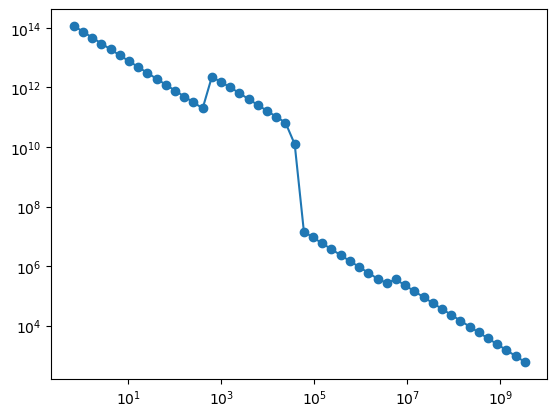

In [144]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')

In [145]:
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x=np.log10(df_grouped_biovol.bin_centers_biovol), y=np.log10(df_grouped_biovol.NB))

In [146]:

# Ensure numeric dtype and drop NaNs or non-positive values
x = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
y = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
mask = (x > 0) & (y > 0)

x_log = np.log10(x[mask])
y_log = np.log10(y[mask])

slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x_log, y_log)

In [147]:
slope_full

-1.281826868501544

In [148]:
intercept_full

14.599349825641141

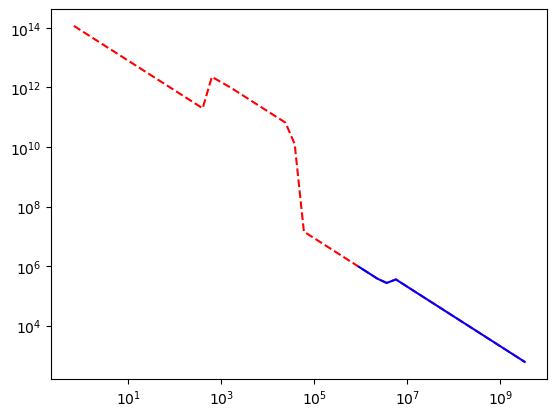

In [149]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], 'r--')
plt.plot(df_grouped_subset['bin_centers_biovol'], df_grouped_subset['NB'], 'b-')
plt.xscale('log')
plt.yscale('log')

In [150]:
df_grouped_biovol_IPSL = df_grouped_biovol
df_grouped_subset_IPSL = df_grouped_subset

del df_grouped_biovol
del df_grouped_subset

In [151]:
# Ensure numeric dtype and drop NaNs or non-positive values
#x = pd.to_numeric(df_grouped_subset['bin_centers_biovol'], errors='coerce')
#y = pd.to_numeric(df_grouped_subset['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
#mask = (x > 0) & (y > 0)

#x_log = np.log10(x[mask])
#y_log = np.log10(y[mask])

#slope_subset, intercept_subset, r_value_subset, p_value_subset, std_err_subset = linregress(x_log, y_log)

## UKESM

In [152]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_UKESM_PSS_hist_biovolume.nc')

In [153]:
ds_hist

<xarray.Dataset>
Dimensions:               (lat: 180, lon: 360, time: 360, biovol_um3: 50)
Coordinates:
  * time                  (time) datetime64[ns] 1985-01-16 ... 2014-12-16
  * lat                   (lat) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                   (lon) float64 -179.5 -178.5 -177.5 ... 178.5 179.5
  * biovol_um3            (biovol_um3) float64 5.316 8.041 ... 3.408e+09
Data variables: (12/19)
    biomes                (lat, lon, time) float64 dask.array<chunksize=(180, 360, 360), meta=np.ndarray>
    chl                   (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    NB                    (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 360, 180, 360), meta=np.ndarray>
    total_biovolume_hist  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    betas_hist            (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    intercept_hist        (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    ...                    ...
    phymisc_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phydiat_per           (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zmicro_per            (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zmeso_per             (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    phyc                  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>
    zooc                  (time, lat, lon) float64 dask.array<chunksize=(360, 180, 360), meta=np.ndarray>

In [154]:
# dictionary with total biovolume
total_biovol_m3={}
total_biovol_m3['globalSum_m3']={}
total_biovol_m3['globalSum_m3']['phymisc'] = ds_hist.phymisc.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['phydiat'] = ds_hist.phydiat.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmicro'] = ds_hist.zmicro.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
total_biovol_m3['globalSum_m3']['zmeso'] = ds_hist.zmeso.median(dim='time').compute().median(dim='lon').compute().median(dim='lat').compute().values
# transform the dictionary to a dataframe
total_biovol_m3=pd.DataFrame.from_dict(total_biovol_m3)
total_biovol_m3=total_biovol_m3.reset_index()
total_biovol_m3.columns.values[0]='name'
total_biovol_m3

,name,globalSum_m3
0,phydiat,179761186778885.75
1,phymisc,396607811531018.1
2,zmeso,18307060414999.96
3,zmicro,10795159224657.01


In [155]:
sizes=np.linspace(np.log10(2),np.log10(2.*1000.),num=1000,endpoint=False)
#10**(sizes)
#sizes

In [156]:
dd=np.diff(sizes)[0]
sizes_min=10**(sizes-dd/2)
sizes_max=10**(sizes+dd/2)
size_range=[str(np.round(10**s,3))+': '+'['+str(np.round(x,3))+','+str(np.round(y,3))+')' for s,x,y in zip(sizes,sizes_min,sizes_max)]
#size_range

In [157]:
sizedf=pd.DataFrame([10**sizes]).transpose()
sizedf.columns=['sizes']
sizedf['phyto']= None
sizedf['zoo']= None
#sizedf.loc[sizedf.sizes < 10,'phyto']='smp'
sizedf.loc[(sizedf.sizes > 2) & (sizedf.sizes < 20),'phyto']='phymisc'
sizedf.loc[(sizedf.sizes > 20) & (sizedf.sizes < 100),'phyto']='phydiat' 
sizedf.loc[(sizedf.sizes > 10) & (sizedf.sizes < 200),'zoo']='zmicro'
sizedf.loc[(sizedf.sizes > 200) & (sizedf.sizes < 2000),'zoo']='zmeso'




sizedf = sizedf.reset_index(drop=True)




In [158]:
sizedf

,sizes,phyto,zoo
0,2.000000,None,None
1,2.013863,phymisc,None
2,2.027823,phymisc,None
3,2.041879,phymisc,None
4,2.056033,phymisc,None
...,...,...,...
995,1932.101758,None,zmeso
996,1945.494448,None,zmeso
997,1958.979971,None,zmeso
998,1972.558971,None,zmeso


In [159]:
# determine the degree of overlap between size bins. In COBALT (and perhaps other models) the degree of overlap might need to be determined following 
# Jessica's method

# the goal is to have repeated entries for a size class if it occurs across plantkon types:
sdfm = pd.melt(sizedf, id_vars='sizes',var_name='type',value_name='name')
sdfm = sdfm.dropna().reset_index(drop=True)
pd.set_option('display.max_rows',80)
sdfm['biovolume_um3']=(4/3)*math.pi*(sdfm.sizes/2)**3
#sdfm

In [160]:
sdfm

,sizes,type,name,biovolume_um3
0,2.013863,phyto,phymisc,4.276501e+00
1,2.027823,phyto,phymisc,4.366049e+00
2,2.041879,phyto,phymisc,4.457472e+00
3,2.056033,phyto,phymisc,4.550809e+00
4,2.070284,phyto,phymisc,4.646101e+00
...,...,...,...,...
1328,1932.101758,zoo,zmeso,3.776492e+09
1329,1945.494448,zoo,zmeso,3.855570e+09
1330,1958.979971,zoo,zmeso,3.936304e+09
1331,1972.558971,zoo,zmeso,4.018728e+09


In [161]:

sdfm['globalSum_m3_split']=0
for s in sdfm.name.unique():
    n=len(sdfm.loc[sdfm.name==s].index)
    print(s, n)
    sdfm.loc[sdfm.name==s,'globalSum_m3_split'] = np.tile(total_biovol_m3.loc[total_biovol_m3.name==s,'globalSum_m3']/n,n)
sdfm

phymisc 333
phydiat 233
zmicro 434
zmeso 333


,sizes,type,name,biovolume_um3,globalSum_m3_split
0,2.013863,phyto,phymisc,4.276501e+00,1191014449042.096436
1,2.027823,phyto,phymisc,4.366049e+00,1191014449042.096436
2,2.041879,phyto,phymisc,4.457472e+00,1191014449042.096436
3,2.056033,phyto,phymisc,4.550809e+00,1191014449042.096436
4,2.070284,phyto,phymisc,4.646101e+00,1191014449042.096436
...,...,...,...,...,...
1328,1932.101758,zoo,zmeso,3.776492e+09,54976157402.402283
1329,1945.494448,zoo,zmeso,3.855570e+09,54976157402.402283
1330,1958.979971,zoo,zmeso,3.936304e+09,54976157402.402283
1331,1972.558971,zoo,zmeso,4.018728e+09,54976157402.402283


In [162]:
sdfm = sdfm.sort_values(by='biovolume_um3', ascending=True)

In [163]:
small_increment_biovol = (sdfm['biovolume_um3'][1]-sdfm['biovolume_um3'][0])/2 # small increment is used to define the maximum and minimum of the size range

In [164]:
# create log-spaced bins for mg_carbon
bins_biovol = np.logspace(np.log10(sdfm['biovolume_um3'].min()-small_increment_biovol), np.log10(sdfm['biovolume_um3'].max()+small_increment_biovol), 51)


# use pandas.cut to bin the data into log-spaced bins
sdfm['biovolume_um3_bin'] = pd.cut(sdfm['biovolume_um3'], bins=bins_biovol, include_lowest=False)
sdfm['bin_centers_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.mid).astype(float) # this gets the mid point 
sdfm['bin_range_biovol'] = sdfm['biovolume_um3_bin'].apply(lambda x:x.length).astype(float)

#len(sdfm)

In [165]:
sdfm.head()

,sizes,type,name,biovolume_um3,globalSum_m3_split,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol
0,2.013863,phyto,phymisc,4.276501,1191014449042.096436,"(4.232, 6.401]",5.3165,2.169
1,2.027823,phyto,phymisc,4.366049,1191014449042.096436,"(4.232, 6.401]",5.3165,2.169
2,2.041879,phyto,phymisc,4.457472,1191014449042.096436,"(4.232, 6.401]",5.3165,2.169
3,2.056033,phyto,phymisc,4.550809,1191014449042.096436,"(4.232, 6.401]",5.3165,2.169
4,2.070284,phyto,phymisc,4.646101,1191014449042.096436,"(4.232, 6.401]",5.3165,2.169


In [166]:
len(sdfm)

1333

In [167]:
df_grouped_biovol = sdfm.groupby(['biovolume_um3_bin','bin_centers_biovol', 'bin_range_biovol']).agg(biovolume_um3=('biovolume_um3','mean'), globalSum_um3=('globalSum_m3_split','sum'),
                                                                                                             sizes=('sizes','mean'))


df_grouped_biovol = df_grouped_biovol.dropna().sort_values(by = ['sizes']).reset_index()
df_grouped_biovol['NB'] = df_grouped_biovol.globalSum_um3/df_grouped_biovol.bin_range_biovol
df_grouped_biovol.sizes = df_grouped_biovol.sizes.round(1)
df_grouped_biovol

# Ensure numeric values
df_grouped_biovol['bin_centers_biovol'] = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
df_grouped_biovol['NB'] = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

df_grouped_subset = df_grouped_biovol[(df_grouped_biovol['bin_centers_biovol'] > 8.2e5) & (df_grouped_biovol['bin_centers_biovol'] < 2.8e13)]

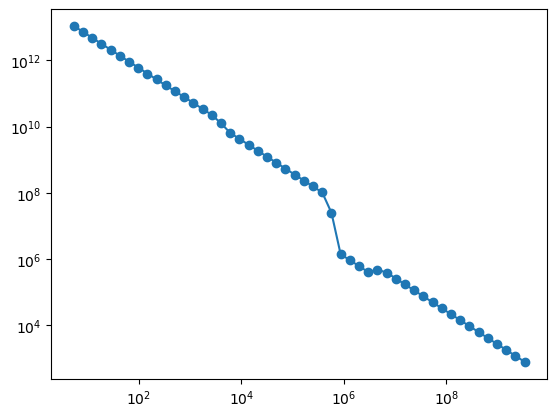

In [168]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')

In [169]:
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x=np.log10(df_grouped_biovol.bin_centers_biovol), y=np.log10(df_grouped_biovol.NB))

In [170]:

# Ensure numeric dtype and drop NaNs or non-positive values
x = pd.to_numeric(df_grouped_biovol['bin_centers_biovol'], errors='coerce')
y = pd.to_numeric(df_grouped_biovol['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
mask = (x > 0) & (y > 0)

x_log = np.log10(x[mask])
y_log = np.log10(y[mask])

slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(x_log, y_log)

In [171]:
slope_full

-1.2206877933337132

In [172]:
intercept_full

14.256689141757022

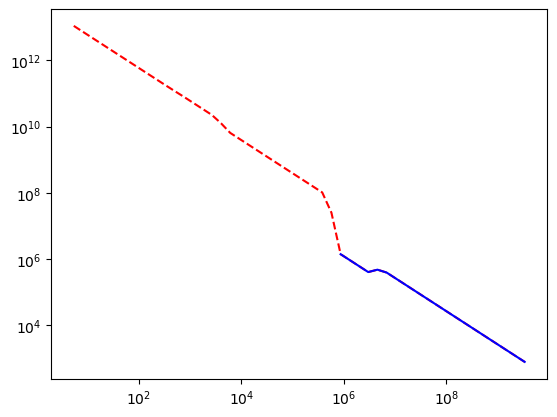

In [173]:
plt.plot(df_grouped_biovol['bin_centers_biovol'], df_grouped_biovol['NB'], 'r--')
plt.plot(df_grouped_subset['bin_centers_biovol'], df_grouped_subset['NB'], 'b-')
plt.xscale('log')
plt.yscale('log')

In [174]:
df_grouped_biovol_UKESM = df_grouped_biovol
df_grouped_subset_UKESM = df_grouped_subset

del df_grouped_biovol
del df_grouped_subset

In [175]:
# Ensure numeric dtype and drop NaNs or non-positive values
#x = pd.to_numeric(df_grouped_subset['bin_centers_biovol'], errors='coerce')
#y = pd.to_numeric(df_grouped_subset['NB'], errors='coerce')

# Filter out non-positive values since log10 is undefined for ≤ 0
#mask = (x > 0) & (y > 0)

#x_log = np.log10(x[mask])
#y_log = np.log10(y[mask])

#slope_subset, intercept_subset, r_value_subset, p_value_subset, std_err_subset = linregress(x_log, y_log)

In [2]:
ds_hist = xr.open_mfdataset('/Users/mc4214/CMIP6_biome_PSS_data/biom_CESM_PSS_hist_biovolume.nc')
ds_hist

<xarray.Dataset>
Dimensions:               (lat: 180, lon: 360, time: 348, biovol_um3: 50)
Coordinates:
  * lat                   (lat) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                   (lon) float64 -179.5 -178.5 -177.5 ... 178.5 179.5
  * biovol_um3            (biovol_um3) float64 0.08765 0.144 ... 3.286e+09
  * time                  (time) datetime64[ns] 1985-01-15 ... 2013-12-15
Data variables: (12/16)
    biomes                (lat, lon, time) float64 dask.array<chunksize=(180, 360, 348), meta=np.ndarray>
    NB                    (biovol_um3, time, lat, lon) float64 dask.array<chunksize=(50, 348, 180, 360), meta=np.ndarray>
    total_biovolume_hist  (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    betas_hist            (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    intercept_hist        (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    R2_hist               (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    ...                    ...
    total_biovolume_full  (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    phypico_per           (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    phydiat_per           (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    zooc_per              (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    phyc                  (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>
    chl                   (time, lat, lon) float64 dask.array<chunksize=(348, 180, 360), meta=np.ndarray>

In [3]:
# 1) Median NB across time, lat, lon → left with dim: biovol_um3
nb_med = ds_hist['NB'].median(dim=('time', 'lat', 'lon'), skipna=True)

# 2) To a tidy 2-column DataFrame: ['biovol_um3', 'NB_median']
df_nb_med = (
    nb_med.compute()          # dask -> concrete
         .rename('NB_median') # column name
         .to_series()         # index = biovol_um3
         .rename_axis('biovol_um3')
         .reset_index()
)

print(df_nb_med.head())

   biovol_um3     NB_median
0     0.08765  1.224384e+14
1     0.14400  7.468740e+13
2     0.23650  4.546189e+13
3     0.38900  2.751641e+13
4     0.63950  1.681067e+13


In [5]:
df_nb_med = df_nb_med.rename(columns={
    'biovol_um3': 'bin_centers_biovol',
    'NB_median': 'NB'
})

In [176]:
## setting up dictionary of model and PFTs
  
# Creating an empty dictionary
NBSS_dict_full = {}

 
# Adding list as value

NBSS_dict_full['CESM'] =  df_nb_med#df_grouped_biovol_CESM
NBSS_dict_full['CMCC'] = df_grouped_biovol_CMCC
NBSS_dict_full['CNRM'] = df_grouped_biovol_CNRM
NBSS_dict_full['GFDL'] = df_grouped_biovol_GFDL
NBSS_dict_full['GISS'] = df_grouped_biovol_GISS
NBSS_dict_full['IPSL'] = df_grouped_biovol_IPSL
NBSS_dict_full['UKESM'] = df_grouped_biovol_UKESM

In [181]:
## setting up dictionary of model and PFTs
  
# Creating an empty dictionary
NBSS_dict_subset = {}

 
# Adding list as value

NBSS_dict_subset['CESM'] = df_grouped_subset_CESM
NBSS_dict_subset['CMCC'] = df_grouped_subset_CMCC
NBSS_dict_subset['CNRM'] = df_grouped_subset_CNRM
NBSS_dict_subset['GFDL'] = df_grouped_subset_GFDL
NBSS_dict_subset['GISS'] = df_grouped_subset_GISS
NBSS_dict_subset['IPSL'] = df_grouped_subset_IPSL
NBSS_dict_subset['UKESM'] = df_grouped_subset_UKESM

In [197]:
NBSS_dict_subset['GFDL']

,biovolume_um3_bin,bin_centers_biovol,bin_range_biovol,biovolume_um3,globalSum_um3,sizes,NB
26,"(979886.508, 1848794.137]",1.414340e+06,8.689076e+05,1.360044e+06,6921379398847.773438,137.0,7.965610e+06
27,"(1848794.137, 3488199.636]",2.668497e+06,1.639405e+06,2.568483e+06,6921379398847.773438,169.3,4.221884e+06
28,"(3488199.636, 6581336.696]",5.034768e+06,3.093137e+06,4.850654e+06,10869734271618.203125,209.2,3.514146e+06
29,"(6581336.696, 12417291.793]",9.499314e+06,5.835955e+06,9.160600e+06,12561886359948.386719,258.6,2.152499e+06
30,"(12417291.793, 23428239.973]",1.792277e+07,1.101095e+07,1.730006e+07,12561886359948.386719,319.7,1.140854e+06
31,"(23428239.973, 44203070.799]",3.381566e+07,2.077483e+07,3.267165e+07,12561886359948.386719,395.2,6.046685e+05
32,"(44203070.799, 83399840.119]",6.380146e+07,3.919677e+07,6.170136e+07,12561886359948.386719,488.4,3.204827e+05
33,"(83399840.119, 157354075.322]",1.203770e+08,7.395424e+07,1.165248e+08,12561886359948.386719,603.8,1.698603e+05
34,"(157354075.322, 296886720.466]",2.271204e+08,1.395326e+08,2.200604e+08,12561886359948.386719,746.3,9.002830e+04
35,"(296886720.466, 560148979.991]",4.285179e+08,2.632623e+08,4.155904e+08,12561886359948.386719,922.4,4.771624e+04


## IDEALIZED BIOVOLUME ESTIMATE

In [178]:
#data from Table 3
coeff_df= pd.read_csv('/Users/mc4214/GIT/CMIP6_size_spectra/data/Table_3.csv')
#source = ['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM', 'PSSdb']
#slope = [-1.07, -1.15, -1.24, -1.15, -1.66, -1.27, -1.19, -1.05]
#intercept = [2.03e13, 3.89e13, 4.09e14, 9.32e14, 4.31e17, 4.02e14, 1.72e14, 3.70e13]
#coeff_df = pd.DataFrame({
#    'source': source,
#    'slope': slope,
#    'intercept': intercept
#})
table_S8_df =coeff_df[coeff_df.experiment=='hist']
table_S8_df

,models,experiment,median_slope,min_slope,max_slope,median_intercept,min_intercept,max_intercept,median_biovolume,min_biovolume,max_biovolume,median_R2,min_R2,max_R2,median_Allbiovolume,min_Allbiovolume,max_Allbiovolume
0,CESM,hist,-1.066118,-1.466350,-0.264979,2.028376e+13,7.270048e+06,1.268659e+15,3.088375e+13,1.781244e+10,3.372568e+14,0.981577,0.336143,0.999719,4.554223e+14,3.910081e+11,6.109840e+16
2,CMCC,hist,-1.145756,-1.414426,-0.964676,3.888084e+13,2.765178e+10,3.987648e+14,4.956904e+13,1.810932e+11,4.244137e+15,0.989522,0.881702,0.996663,2.790459e+14,7.222574e+11,1.756437e+16
4,CNRM,hist,-1.242919,-1.470693,-0.865880,4.088973e+14,8.347489e+12,6.734215e+15,2.401478e+13,1.132971e+12,6.015158e+15,0.932526,0.771298,0.983404,9.631971e+15,8.220809e+14,2.045404e+18
6,GFDL,hist,-1.154270,-1.381293,-0.902864,9.319725e+14,1.369770e+08,3.392084e+16,1.692542e+14,4.148979e+09,1.614386e+15,0.990145,0.912846,0.998057,1.174877e+16,1.450193e+10,7.886490e+17
8,GISS,hist,-1.661466,-3.454392,-0.662548,4.305864e+17,1.071894e+10,1.301075e+22,1.075037e+13,1.218806e+02,4.798641e+14,0.948866,0.737606,0.996211,8.666663e+16,2.095738e+11,1.032438e+19
10,IPSL,hist,-1.270359,-1.479045,-1.057045,4.021846e+14,9.577349e+12,1.043512e+16,1.546230e+13,7.709334e+11,2.817074e+14,0.933679,0.764739,0.977038,7.047032e+15,7.136052e+14,1.158334e+18
12,UKESM,hist,-1.193493,-2.808519,-0.948201,1.718096e+14,3.739233e+10,9.829720e+15,2.188143e+13,1.305079e+02,3.518740e+14,0.985188,0.846083,0.995893,6.559373e+14,2.579065e+11,8.987511e+15


In [5]:
## new suggested method: get the integral between 116-2000 um
def biovolume_integral(m, b, x1, x2):
    """Area under y=b*x^m vs x (total biovolume per m^2) over [x1,x2]."""
    if math.isclose(m, -1.0, rel_tol=1e-12):
        # Limit as m→-1 is b*ln(x2/x1)
        return b * math.log(x2/x1)
    return (b/(m+1)) * (x2**(m+1) - x1**(m+1))

In [10]:
# apply this to the coeff_df
x1, x2 = 8.2e5, 4.2e9 # size range in biovolume units

table_S8_df['integrated_biovolume']=table_S8_df.apply(lambda r: biovolume_integral(r['median_slope'], r['median_intercept'], x1, x2),axis=1)
table_S8_df

,models,experiment,median_slope,min_slope,max_slope,median_intercept,min_intercept,max_intercept,median_biovolume,min_biovolume,max_biovolume,median_R2,min_R2,max_R2,median_Allbiovolume,min_Allbiovolume,max_Allbiovolume,integrated_biovolume
0,CESM,hist,-1.066118,-1.466350,-0.264979,2.028376e+13,7.270048e+06,1.268659e+15,3.088375e+13,1.781244e+10,3.372568e+14,0.981577,0.336143,0.999719,4.554223e+14,3.910081e+11,6.109840e+16,5.380058e+13
2,CMCC,hist,-1.145756,-1.414426,-0.964676,3.888084e+13,2.765178e+10,3.987648e+14,4.956904e+13,1.810932e+11,4.244137e+15,0.989522,0.881702,0.996663,2.790459e+14,7.222574e+11,1.756437e+16,2.609997e+13
4,CNRM,hist,-1.242919,-1.470693,-0.865880,4.088973e+14,8.347489e+12,6.734215e+15,2.401478e+13,1.132971e+12,6.015158e+15,0.932526,0.771298,0.983404,9.631971e+15,8.220809e+14,2.045404e+18,5.386373e+13
6,GFDL,hist,-1.154270,-1.381293,-0.902864,9.319725e+14,1.369770e+08,3.392084e+16,1.692542e+14,4.148979e+09,1.614386e+15,0.990145,0.912846,0.998057,1.174877e+16,1.450193e+10,7.886490e+17,5.413203e+14
8,GISS,hist,-1.661466,-3.454392,-0.662548,4.305864e+17,1.071894e+10,1.301075e+22,1.075037e+13,1.218806e+02,4.798641e+14,0.948866,0.737606,0.996211,8.666663e+16,2.095738e+11,1.032438e+19,7.947574e+13
10,IPSL,hist,-1.270359,-1.479045,-1.057045,4.021846e+14,9.577349e+12,1.043512e+16,1.546230e+13,7.709334e+11,2.817074e+14,0.933679,0.764739,0.977038,7.047032e+15,7.136052e+14,1.158334e+18,3.374393e+13
12,UKESM,hist,-1.193493,-2.808519,-0.948201,1.718096e+14,3.739233e+10,9.829720e+15,2.188143e+13,1.305079e+02,3.518740e+14,0.985188,0.846083,0.995893,6.559373e+14,2.579065e+11,8.987511e+15,5.149452e+13


In [8]:
#Now get analytical estimate of the biovolume for PSSbd:
df_pssdb = pd.read_csv('/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/PSSdb_data_full.csv', sep= ',')
x1, x2 = 8.2e5, 4.2e9 # size range in biovolume units
#int_biovol = biovolume_integral(np.nanmedian(df_pssdb.slope), np.nanmedian(10**(df_pssdb.intercept)), x1, x2)
int_biovol = biovolume_integral(-1.021, 3.24e13, x1, x2)
print(f"{int_biovol:2e}")
#print(np.nanmedian(df_pssdb.slope))
#print(f"{np.nanmedian(10**df_pssdb.intercept):2e}")

1.903318e+14


In [184]:
PSSdb_1a_files = glob('/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/*1a*.csv')
PSSdb_1a_files = [x for x in PSSdb_1a_files if 'IFCB' not in x]

In [185]:
PSSdb_1a_files

['/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/UVP_1a_Size-distribution_v2024-04.csv',
 '/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/Scanner_1a_Size-distribution_v2024-04.csv']

In [186]:
PSSdb_1a_files

['/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/UVP_1a_Size-distribution_v2024-04.csv',
 '/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/Scanner_1a_Size-distribution_v2024-04.csv']

In [187]:
df_1a=pd.concat(map((lambda path: (pd.read_csv(path))), PSSdb_1a_files)).reset_index(drop=True)
df_1a['normalized_biovolume_mean_depth_int'] = (df_1a['normalized_biovolume_mean']/0.001)* df_1a['max_depth']# depth integrtation, remember values go from liters to squared meters

In [188]:
df_1a

,year,month,latitude,longitude,ocean,min_depth,max_depth,n,biovolume_size_class,normalized_biovolume_mean,normalized_biovolume_std,equivalent_circular_diameter_mean,normalized_abundance_mean,normalized_abundance_std,QC_3std_dev,QC_min_n_size_bins,QC_R2,Unnamed: 17,normalized_biovolume_mean_depth_int
0,2008,7,22.5,-157.5,North Pacific Ocean,1.0,201.0,1,5.271000e+07,6.325000,NaN,459.2,0.751700,NaN,0,0,0,NaN,1271325.00
1,2008,7,22.5,-157.5,North Pacific Ocean,1.0,201.0,1,1.054000e+08,4.984000,NaN,578.5,0.591800,NaN,0,0,0,NaN,1001784.00
2,2008,7,22.5,-157.5,North Pacific Ocean,1.0,201.0,1,2.108000e+08,3.178000,NaN,728.9,0.334100,NaN,0,0,0,NaN,638778.00
3,2008,7,22.5,-157.5,North Pacific Ocean,1.0,201.0,1,4.217000e+08,1.729000,NaN,918.4,0.162900,NaN,0,0,0,NaN,347529.00
4,2008,7,22.5,-157.5,North Pacific Ocean,1.0,201.0,1,8.433000e+08,0.225600,NaN,1157.0,0.025200,NaN,0,0,0,NaN,45345.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21764,2022,5,0.5,-43.5,North Atlantic Ocean,0.0,200.0,1,6.747000e+09,0.003647,NaN,2314.0,0.000266,NaN,0,0,0,NaN,729.40
21765,2022,5,0.5,-43.5,North Atlantic Ocean,0.0,200.0,1,1.349000e+10,0.001079,NaN,2916.0,0.000072,NaN,0,0,0,NaN,215.80
21766,2022,5,0.5,-43.5,North Atlantic Ocean,0.0,200.0,1,2.699000e+10,0.000437,NaN,3673.0,0.000026,NaN,0,0,0,NaN,87.32
21767,2022,5,0.5,-43.5,North Atlantic Ocean,0.0,200.0,1,5.397000e+10,0.000297,NaN,4628.0,0.000017,NaN,0,0,0,NaN,59.42


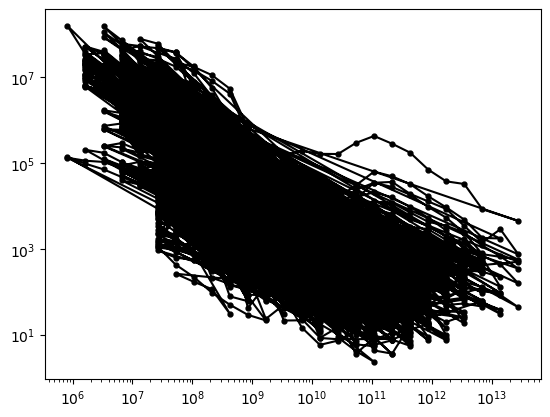

In [189]:
plt.plot(df_1a['biovolume_size_class'], df_1a['normalized_biovolume_mean_depth_int'],
            'k-', marker='o', markersize=3.5, label='Full')
plt.xscale('log')
plt.yscale('log')

In [190]:
df_1a_summary=df_1a.astype(dict(zip(['biovolume_size_class'],[str]*1))).groupby(['biovolume_size_class']).apply(lambda x: pd.Series({'NB':np.nanmedian(x.normalized_biovolume_mean_depth_int)})).reset_index()


In [191]:
df_1a_summary = (
    df_1a_summary
      .rename(columns={'biovolume_size_class': 'bin_centers_biovol'})
      .assign(bin_centers_biovol=lambda d: pd.to_numeric(d['bin_centers_biovol'], errors='coerce'))
      .sort_values('bin_centers_biovol')
      .reset_index(drop=True)
)
df_1a_summary
NBSS_dict_full['PSSdb'] = df_1a_summary

In [192]:
NBSS_dict_full['PSSdb']

,bin_centers_biovol,NB
0,8.235000e+05,1.384500e+05
1,1.647000e+06,1.623176e+07
2,3.294000e+06,1.007512e+07
3,6.588000e+06,2.773800e+06
4,1.318000e+07,1.006206e+06
5,2.635000e+07,8.160525e+05
6,5.271000e+07,2.642145e+05
7,1.054000e+08,1.482190e+05
8,2.108000e+08,7.440900e+04
9,4.217000e+08,2.636115e+04


## integrate intercept and biovolume values, so they match units from model data (from Liters to m^2)

In [357]:
# Estimate the 'Idealized Normalized Biovolume' and use it to get theoretical subsetted Biovolume from the Models
#if their biovolume values followed the same distribution as PSSdb's biovolume
log10_biovol = np.log10(df_1a['biovolume_size_class'].replace(0, np.nan))
meanlog = np.nanmean(log10_biovol)
sdlog = np.nanstd(log10_biovol)

# Convert base-10 stats to natural log
mean_ln = meanlog * np.log(10)
sd_ln = sdlog * np.log(10)

# Seed
i = 0
np.random.seed(i)

# Output lists
sources = []
biovols = []
rows = []

# Loop over models
for _, row in coeff_df.iterrows():
    s = row['source']
    slope = row['slope']
    intercept = row['log10_intercept']
    
    # Generate random log-normal biovolume
    random_biovol = np.random.lognormal(mean=mean_ln + i, sigma=sd_ln + i, size=len(df_1a))
    log10_random = np.log10(random_biovol)
    
    # Rescale log10(random_log_biovolume) to match observed log10_biovol range
    obs_min, obs_max = np.nanmin(log10_biovol), np.nanmax(log10_biovol)
    sim_min, sim_max = np.min(log10_random), np.max(log10_random)

    # Apply min-max scaling to log10_random
    log10_random_rescaled = ((log10_random - sim_min) / (sim_max - sim_min)) * (obs_max - obs_min) + obs_min
    random_biovol_rescaled = np.sort(10 ** log10_random_rescaled)

    
    # Compute logNB
    logNB = slope * np.log10(random_biovol_rescaled) + intercept
    
    NB = 10**logNB
    
    # create log-spaced bins for mg_carbon
    small_increment_biovol = (random_biovol_rescaled[1]-random_biovol_rescaled[0])/2
    bins_biovol = np.logspace(np.log10(random_biovol_rescaled.min()-small_increment_biovol), np.log10(random_biovol_rescaled.max()+small_increment_biovol), 51)

    # Bin the rescaled biovolume values
    bin_labels = pd.cut(random_biovol_rescaled, bins=bins_biovol, include_lowest=False)

    # Get bin metadata
    bin_centers = bin_labels.map(lambda x: x.mid if pd.notnull(x) else np.nan)
    bin_ranges = bin_labels.map(lambda x: x.length if pd.notnull(x) else np.nan)

    # Final theoretical biovolume using bin width
    biovol = NB * bin_ranges.astype(float)
    
    temp_df = pd.DataFrame({
    'biovol': random_biovol_rescaled,
    'NB': NB,
    'source': s,
    'theoretical_biovol': biovol,
    'bin_centers_biovol': bin_centers,
    'bin_range_biovol': bin_ranges
    })
    
    # Store results
    sources.append(s)
    biovols.append(np.sum(biovol))
    rows.append(temp_df)

# Build final DataFrame
biovol_df = pd.DataFrame({
    'source': sources,
    'theoretical_biovolume': biovols
})

plot_df = pd.concat(rows, ignore_index=True)
plot_df = plot_df.sort_values(by=['source','theoretical_biovol']).reset_index(drop=True)

ValueError: Bin edges must be unique: array([           nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan, 2.76300014e+13]).
You can drop duplicate edges by setting the 'duplicat

In [ ]:
plot_df

In [ ]:
# get the corrected theoretical slopes and intercepts
from scipy.stats import linregress

# Create empty lists to store results
slope_list = []
intercept_list = []

# Group by source
for s, group in plot_df.groupby('source'):
    x = np.log10(group['theoretical_biovol'])
    y = group['theoretical_NB']
    
    # Linear regression
    slope, intercept, _, _, _ = linregress(x, y)
    
    # Fill columns with constant values for each row in the group
    slope_list.extend([slope] * len(group))
    intercept_list.extend([intercept] * len(group))

# Add to plot_df
plot_df['slope_theoretical'] = slope_list
plot_df['intercept_theoretical'] = intercept_list

In [ ]:
theoretical_coeffs_df = plot_df.groupby('source').agg({
    'slope_theoretical': 'first',
    'intercept_theoretical': 'first'
}).reset_index()
theoretical_coeffs_df['intercept_theoretical'] = 10**(theoretical_coeffs_df['intercept_theoretical'])
theoretical_coeffs_df

In [ ]:
biovol_sum_df=plot_df.groupby('source')['theoretical_biovol'].sum().reset_index()

In [ ]:
biovol_sum_df

In [ ]:
# --- Generate random log-normal biovolumes for plotting ---
i = 0
log10_biovol = np.log10(df_1a.biovolume_size_class.replace(0, np.nan))  # Avoid log(0)
meanlog = np.nanmean(log10_biovol)
sdlog = np.nanstd(log10_biovol)

#np.random.seed(i)
#random_log_biovolume = np.random.lognormal(mean=meanlog + i, sigma=sdlog + i, size=len(d))
#log10_random = np.log10(random_log_biovolume)
mean_ln = meanlog * np.log(10)
sd_ln = sdlog * np.log(10)

np.random.seed(i)
random_log_biovolume = np.random.lognormal(mean=mean_ln, sigma=sd_ln, size=len(d))
log10_random = np.log10(random_log_biovolume)

In [ ]:
# Generate as usual
np.random.seed(i)
random_log_biovolume = np.random.lognormal(mean=meanlog + i, sigma=sdlog + i, size=len(d))
log10_random = np.log10(random_log_biovolume)

# Rescale log10(random_log_biovolume) to match observed log10_biovol range
obs_min, obs_max = np.nanmin(log10_biovol), np.nanmax(log10_biovol)
sim_min, sim_max = np.min(log10_random), np.max(log10_random)

# Apply min-max scaling to log10_random
log10_random_rescaled = ((log10_random - sim_min) / (sim_max - sim_min)) * (obs_max - obs_min) + obs_min

# Back-transform to biovolume
random_log_biovolume_rescaled = 10 ** log10_random_rescaled



In [ ]:
rows = []

for _, row in coeff_df.iterrows():
    s = row['source']
    slope = row['slope']
    intercept = row['log10_intercept']

    logNB = slope * log10_random_rescaled + intercept

    temp_df = pd.DataFrame({
        'log10_biovol': log10_random_rescaled, # log10_random,
        'logNB': logNB,
        'source': s
    })

    rows.append(temp_df)

plot_df = pd.concat(rows, ignore_index=True)

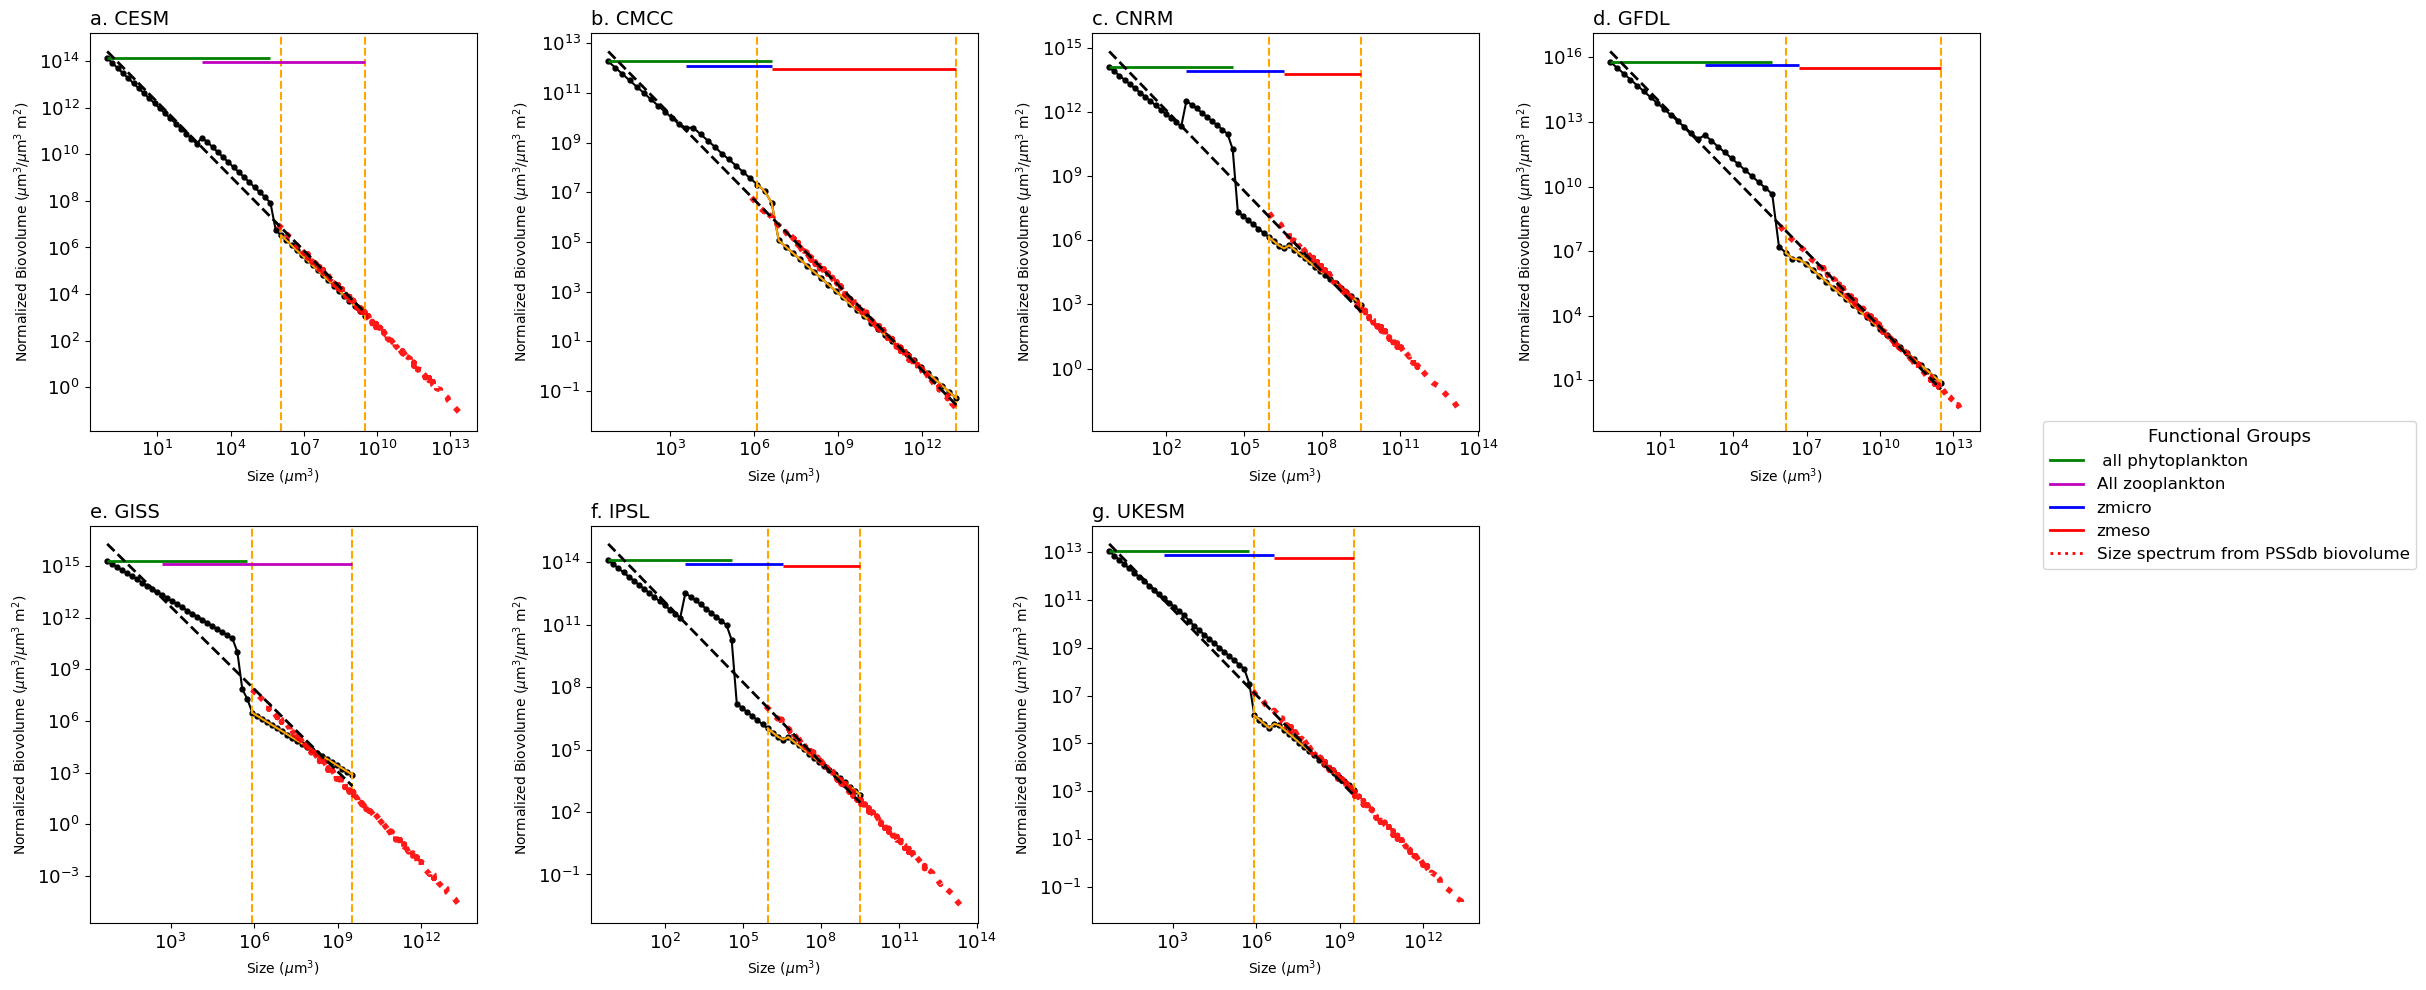

In [991]:
from matplotlib.lines import Line2D
# Define models and panel labels
models = ['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM']
letters = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.', 'g.']

# Create 2x4 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # Flatten to index easily

# Loop over models and axes
for idx, model in enumerate(models):
    ax = axes[idx]

    df_full = NBSS_dict_full[model]
    df_subset = NBSS_dict_subset[model]

    # Red dashed full line with markers
    ax.plot(df_full['bin_centers_biovol'], df_full['NB'],
            'k-', marker='o', markersize=3.5, label='Full')

    # Blue solid subset line
    ax.plot(df_subset['bin_centers_biovol'], df_subset['NB'], color = 'orange',
            linestyle='-', label='Subset')

    # Log scale
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Vertical orange lines around subset
    x_min = df_subset['bin_centers_biovol'].min()
    x_max = df_subset['bin_centers_biovol'].max()
    ax.axvline(x=x_min, color='orange', linestyle='--')
    ax.axvline(x=x_max, color='orange', linestyle='--')
    x_min_PSSdb = df_subset['bin_centers_biovol'].min()
    x_max_PSSdb = df_subset['bin_centers_biovol'].max()
    ax.axvline(x=x_min_PSSdb, color='orange', linestyle='--')
    ax.axvline(x=x_max_PSSdb, color='orange', linestyle='--')
    
    #Next four lines are for idealized biovol
    df_sim = plot_df[plot_df['source'] == model].sort_values(by='bin_centers_biovol')
    
    x_sim = df_sim['bin_centers_biovol']  # Convert back to biovolume
    #x_sim = df_sim['theoretical_biovol'] 

    y_sim = df_sim['NB']         # Convert back to NB
    #y_sim = df_sim['theoretical_NB']
    
    ax.plot(x_sim, y_sim,linestyle=':', linewidth=4,color='r', alpha=0.9, label='PSSdb idealized biovolume') 
    
    if model == 'CESM':
            y_max = df_full['NB'].max()
            phyto_min = df_full.loc[(df_full['sizes'] - 0.5).abs().idxmin(), 'bin_centers_biovol']
            phyto_max = df_full.loc[(df_full['sizes'] - 100).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max, xmin=phyto_min, xmax=phyto_max, color='g', linestyle='-', linewidth=2)
            
            zoo_min = df_full.loc[(df_full['sizes'] - 10).abs().idxmin(), 'bin_centers_biovol']
            zoo_max = df_full.loc[(df_full['sizes'] - 2000).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/1.5, xmin=zoo_min, xmax=zoo_max, color='m', linestyle='-', linewidth=2)
            
    if model == 'CMCC':
            y_max = df_full['NB'].max()
            phyto_min = df_full.loc[(df_full['sizes'] - 2).abs().idxmin(), 'bin_centers_biovol']
            phyto_max = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max, xmin=phyto_min, xmax=phyto_max, color='g', linestyle='-', linewidth=2)
            
            microzoo_min = df_full.loc[(df_full['sizes'] - 20).abs().idxmin(), 'bin_centers_biovol']
            microzoo_max = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/1.5, xmin=microzoo_min, xmax=microzoo_max, color='b', linestyle='-', linewidth=2)
            
            zoo_min = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            zoo_max = df_full.loc[(df_full['sizes'] - 35000).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/2, xmin=zoo_min, xmax=zoo_max, color='r', linestyle='-', linewidth=2)
            
    if model in ['CNRM', 'IPSL']:
            y_max = df_full['NB'].max()
            phyto_min = df_full.loc[(df_full['sizes'] - 1).abs().idxmin(), 'bin_centers_biovol']
            phyto_max = df_full.loc[(df_full['sizes'] - 40).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max, xmin=phyto_min, xmax=phyto_max, color='g', linestyle='-', linewidth=2)
            
            microzoo_min = df_full.loc[(df_full['sizes'] - 10).abs().idxmin(), 'bin_centers_biovol']
            microzoo_max = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/1.5, xmin=microzoo_min, xmax=microzoo_max, color='b', linestyle='-', linewidth=2)
            
            zoo_min = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            zoo_max = df_full.loc[(df_full['sizes'] - 2000).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/2, xmin=zoo_min, xmax=zoo_max, color='r', linestyle='-', linewidth=2)        

    if model == 'GFDL':
            y_max = df_full['NB'].max()
            phyto_min = df_full.loc[(df_full['sizes'] - 0.5).abs().idxmin(), 'bin_centers_biovol']
            phyto_max = df_full.loc[(df_full['sizes'] - 100).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max, xmin=phyto_min, xmax=phyto_max, color='g', linestyle='-', linewidth=2)
            
            microzoo_min = df_full.loc[(df_full['sizes'] - 10).abs().idxmin(), 'bin_centers_biovol']
            microzoo_max = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/1.5, xmin=microzoo_min, xmax=microzoo_max, color='b', linestyle='-', linewidth=2)
            
            zoo_min = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            zoo_max = df_full.loc[(df_full['sizes'] - 20000).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/2, xmin=zoo_min, xmax=zoo_max, color='r', linestyle='-', linewidth=2)
            
    if model == 'GISS':
            y_max = df_full['NB'].max()
            phyto_min = df_full.loc[(df_full['sizes'] - 2).abs().idxmin(), 'bin_centers_biovol']
            phyto_max = df_full.loc[(df_full['sizes'] - 100).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max, xmin=phyto_min, xmax=phyto_max, color='g', linestyle='-', linewidth=2)
            
            zoo_min = df_full.loc[(df_full['sizes'] - 10).abs().idxmin(), 'bin_centers_biovol']
            zoo_max = df_full.loc[(df_full['sizes'] - 2000).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/1.5, xmin=zoo_min, xmax=zoo_max, color='m', linestyle='-', linewidth=2)
            
    if model == 'UKESM':
            y_max = df_full['NB'].max()
            phyto_min = df_full.loc[(df_full['sizes'] - 2).abs().idxmin(), 'bin_centers_biovol']
            phyto_max = df_full.loc[(df_full['sizes'] - 100).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max, xmin=phyto_min, xmax=phyto_max, color='g', linestyle='-', linewidth=2)
            
            microzoo_min = df_full.loc[(df_full['sizes'] - 10).abs().idxmin(), 'bin_centers_biovol']
            microzoo_max = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/1.5, xmin=microzoo_min, xmax=microzoo_max, color='b', linestyle='-', linewidth=2)
            
            zoo_min = df_full.loc[(df_full['sizes'] - 200).abs().idxmin(), 'bin_centers_biovol']
            zoo_max = df_full.loc[(df_full['sizes'] - 2000).abs().idxmin(), 'bin_centers_biovol']
            ax.hlines(y=y_max/2, xmin=zoo_min, xmax=zoo_max, color='r', linestyle='-', linewidth=2)

    # Linear regression (log-log) on full data
    x = df_full['bin_centers_biovol']
    y = df_full['NB']
    mask = (x > 0) & (y > 0)
    x_log = np.log10(x[mask])
    y_log = np.log10(y[mask])
    slope, intercept = np.polyfit(x_log, y_log, 1)
    x_fit = np.linspace(x_log.min(), x_log.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(10**x_fit, 10**y_fit, 'k--', linewidth=2)

    # Panel label and title
    ax.set_title(f"{letters[idx]} {model}", loc='left', fontsize=14)

    ax.set_xlabel(r'Size ($\mu$m$^3$)', fontsize=10)
    ax.set_ylabel(r'Normalized Biovolume ($\mu$m$^3$/$\mu$m$^3$ m$^2$)', fontsize=10)
    ax.tick_params(axis='both', labelsize=13)

# Remove the unused 8th panel
fig.delaxes(axes[-1])

# Custom legend handles for horizontal bars
custom_lines = [
    Line2D([0], [0], color='g', lw=2, linestyle='-', label=' all phytoplankton'),
    Line2D([0], [0], color='m', lw=2, linestyle='-', label='All zooplankton'),
    Line2D([0], [0], color='b', lw=2, linestyle='-', label='zmicro'),
    Line2D([0], [0], color='r', lw=2, linestyle='-', label='zmeso'),
    Line2D([0], [0], color='r', lw=2, linestyle=':', label='Size spectrum from PSSdb biovolume')
]

# Add legend to figure (outside or inside a panel — you choose)
fig.legend(handles=custom_lines, title='Functional Groups',
           loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=12, title_fontsize=13)


output_path = '/Users/mc4214/GIT/CMIP6_size_spectra/figures/fig_supp_biovol_discrepancy.png'

plt.tight_layout()
fig.savefig(output_path, dpi=300, bbox_inches='tight')  # This preserves legend
plt.show()  

KeyError: 'PSSdb'

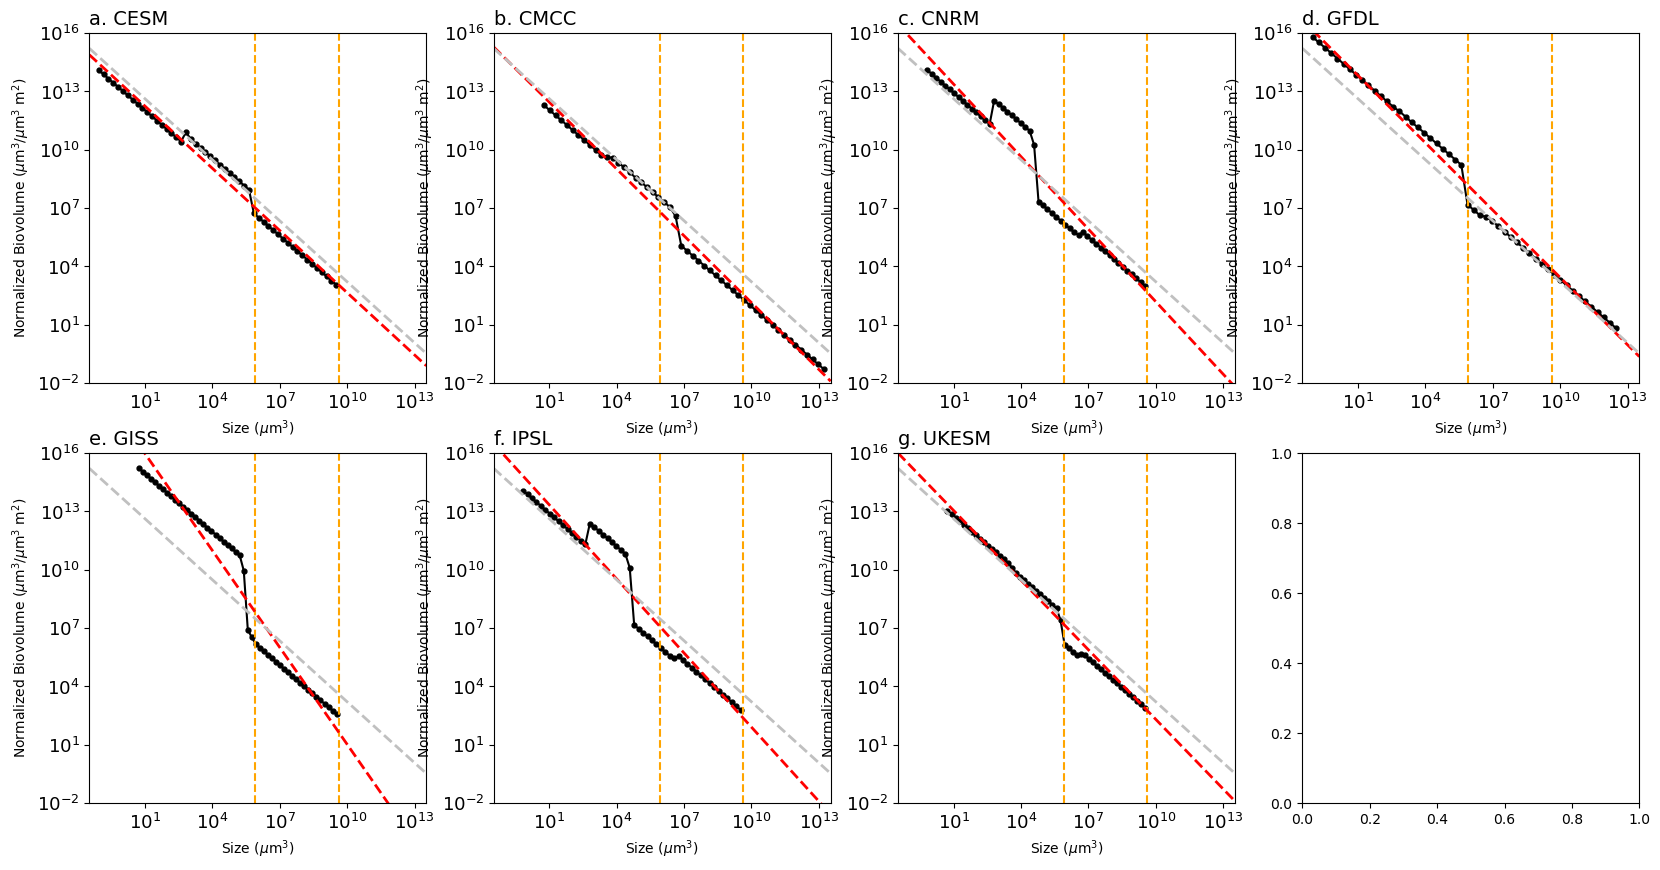

In [179]:
from matplotlib.lines import Line2D
# Define models and panel labels
models = ['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM', 'PSSdb']
letters = ['a.', 'b.', 'c.', 'd.', 'e.', 'f.', 'g.', 'h.']

# Create 2x4 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # Flatten to index easily

# Loop over models and axes
for idx, model in enumerate(models):
    ax = axes[idx]

    df_full = NBSS_dict_full[model]
    #df_subset = NBSS_dict_subset[model]

    # Red dashed full line with markers
    ax.plot(df_full['bin_centers_biovol'], df_full['NB'],
            'k-', marker='o', markersize=3.5, label='Full')

    # Blue solid subset line
    #ax.plot(df_subset['bin_centers_biovol'], df_subset['NB'], color = 'orange', linestyle='-', label='Subset')

    # Vertical orange lines around subset
    ax.axvline(8.2e5, color='orange', linestyle='--')
    ax.axvline(4.2e9, color='orange', linestyle='--')
    
    # Log scale
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    #Limits of the full range of size classes
    um_min=(4/3)*math.pi*(0.4/2)**3
    um_max=(4/3)*math.pi*(40000/2)**3
    
    #fit of the models
    if model != 'PSSdb':
        m=table_S8_df.median_slope[table_S8_df.models == model].values[0]
        b=table_S8_df.median_intercept[table_S8_df.models == model].values[0]
        x_fit = np.geomspace(um_min, um_max, 200)  # evenly spaced on log-x
        y_fit = b * x_fit**m
        ax.plot(x_fit, y_fit, '--', linewidth=2, color='red')

    # Linear regression (log-log) on full data
    # --- Fixed size-spectrum line across all panels ---
    m_PSSdb = -1.046062
    b_PSSdb = 4.646196e13  # since intercept = log10(3.70e13)


    #xpos = df_full.loc[df_full['bin_centers_biovol'] > 0, 'bin_centers_biovol']
    x_fit_PSSdb = np.geomspace(um_min, um_max, 200)  # evenly spaced on log-x
    y_fit_PSSdb = b_PSSdb * x_fit**m_PSSdb

    ax.plot(x_fit_PSSdb, y_fit_PSSdb, '--', linewidth=2, color='silver')

    # Panel label and title
    ax.set_title(f"{letters[idx]} {model}", loc='left', fontsize=14)

    ax.set_xlabel(r'Size ($\mu$m$^3$)', fontsize=10)
    ax.set_ylabel(r'Normalized Biovolume ($\mu$m$^3$/$\mu$m$^3$ m$^2$)', fontsize=10)
    ax.tick_params(axis='both', labelsize=13)

    ax.set_xlim(um_min, um_max)
    ax.set_ylim(0.01, 1e16)
    

# Custom legend handles for horizontal bars
custom_lines = [
    Line2D([0], [0], color='g', lw=2, linestyle='-', label=' all phytoplankton'),
    Line2D([0], [0], color='m', lw=2, linestyle='-', label='All zooplankton'),
    Line2D([0], [0], color='b', lw=2, linestyle='-', label='zmicro'),
    Line2D([0], [0], color='r', lw=2, linestyle='-', label='zmeso'),
    Line2D([0], [0], color='silver', lw=2, linestyle='--', label='Size spectrum from observations')
]

# Add legend to figure (outside or inside a panel — you choose)
fig.legend(handles=custom_lines, title='',
           loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=12, title_fontsize=13)


#output_path = '/Users/mc4214/GIT/CMIP6_size_spectra/figures/fig_supp_biovol_discrepancy_ver2.png'

plt.tight_layout()
fig.savefig(output_path, dpi=300, bbox_inches='tight')  # This preserves legend
plt.show()  

In [196]:
np.log10(3.7e13)

13.568201724066995